# Module-2 | Notebook 03 — Exploratory Data Analysis (EDA)

**Purpose:** Comprehensive EDA on the preprocessed COCO 2014 and RefCOCO datasets  
**Depends on:** `02_data_preprocessing.ipynb` (produces the CSV files this notebook reads)  
**Author:** NLP Research Project — Module 2  

---

### Ground Rules
- Input: `module-2/outputs/coco_processed.csv` and `module-2/outputs/refcoco_processed.csv`
- Output: `module-2/outputs/eda/` — all plots and summary tables
- Raw datasets under `module-2/datasets/` are **never touched**
- Preprocessed CSVs are **never overwritten**
- No model training; no additional preprocessing

### Sections
1. Environment & Data Load
2. COCO Dataset EDA (images, annotations, categories, bboxes)
3. RefCOCO EDA (splits, categories, expressions, bboxes)
4. COCO ↔ RefCOCO Relationship EDA
5. Text-Specific Linguistic Analysis
6. Data Quality Analysis
7. Save EDA Outputs
8. Final EDA Summary
9. Agent Task Summary


---
## Section 1 — Environment Setup & Data Load

**What:** Import libraries, define paths, create the `outputs/eda/` directory, and load both preprocessed CSVs.

**Why:** Centralising all imports and paths at the top makes the notebook fully reproducible — run it fresh on any machine and it produces identical output.

**Variables after this section:**
- `coco_df` — COCO processed annotation table
- `refcoco_df` — RefCOCO processed expression table
- `EDA_DIR` — output directory for all plots and summaries

**Expected output:** Shape, dtypes, null counts, and descriptive stats for both DataFrames.


In [147]:
# Standard Library
import sys, os, re, warnings
from pathlib import Path
from collections import Counter

# Third-party
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams.update({
    'figure.dpi'     : 110,
    'figure.figsize' : (12, 5),
    'font.size'      : 11,
})
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 90)
pd.set_option('display.float_format', '{:.4f}'.format)

print(f'Python     : {sys.version}')
print(f'NumPy      : {np.__version__}')
print(f'Pandas     : {pd.__version__}')
print(f'Matplotlib : {matplotlib.__version__}')


Python     : 3.13.1 (tags/v3.13.1:0671451, Dec  3 2024, 19:06:28) [MSC v.1942 64 bit (AMD64)]
NumPy      : 2.3.2
Pandas     : 2.3.1
Matplotlib : 3.10.5


In [148]:
# ── Paths ─────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path(os.getcwd())          # module-2/ipynb/
MODULE2_DIR  = NOTEBOOK_DIR.parent        # module-2/
OUTPUTS_DIR  = MODULE2_DIR / 'outputs'    # module-2/outputs/
EDA_DIR      = OUTPUTS_DIR / 'eda'        # module-2/outputs/eda/

COCO_CSV    = OUTPUTS_DIR / 'coco_processed.csv'
REFCOCO_CSV = OUTPUTS_DIR / 'refcoco_processed.csv'

EDA_DIR.mkdir(parents=True, exist_ok=True)

print('Path check:')
for label, p in [
    ('coco_processed.csv   ', COCO_CSV),
    ('refcoco_processed.csv', REFCOCO_CSV),
    ('EDA output dir       ', EDA_DIR),
]:
    print(f'  {label} : exists={p.exists()}  path={p}')


Path check:
  coco_processed.csv    : exists=True  path=d:\NLP-Research\module-2\outputs\coco_processed.csv
  refcoco_processed.csv : exists=True  path=d:\NLP-Research\module-2\outputs\refcoco_processed.csv
  EDA output dir        : exists=True  path=d:\NLP-Research\module-2\outputs\eda


In [149]:
# ── Load preprocessed CSVs ────────────────────────────────────────────────────
coco_df    = pd.read_csv(COCO_CSV)
refcoco_df = pd.read_csv(REFCOCO_CSV)

print('COCO processed DataFrame')
print(f'  Shape   : {coco_df.shape}')
print(f'  Columns : {list(coco_df.columns)}')
print()
print('RefCOCO processed DataFrame')
print(f'  Shape   : {refcoco_df.shape}')
print(f'  Columns : {list(refcoco_df.columns)}')


COCO processed DataFrame
  Shape   : (604906, 11)
  Columns : ['image_id', 'image_path', 'width', 'height', 'ann_id', 'bbox_x', 'bbox_y', 'bbox_width', 'bbox_height', 'category_id', 'category_name']

RefCOCO processed DataFrame
  Shape   : (267568, 12)
  Columns : ['image_id', 'image_path', 'ann_id', 'bbox_x', 'bbox_y', 'bbox_width', 'bbox_height', 'category_id', 'category_name', 'referring_expression', 'split', 'source']


In [150]:
# ── Data types ────────────────────────────────────────────────────────────────
print('COCO dtypes:')
print(coco_df.dtypes)
print()
print('RefCOCO dtypes:')
print(refcoco_df.dtypes)


COCO dtypes:
image_id           int64
image_path        object
width              int64
height             int64
ann_id             int64
bbox_x           float64
bbox_y           float64
bbox_width       float64
bbox_height      float64
category_id        int64
category_name     object
dtype: object

RefCOCO dtypes:
image_id                  int64
image_path               object
ann_id                    int64
bbox_x                  float64
bbox_y                  float64
bbox_width              float64
bbox_height             float64
category_id               int64
category_name            object
referring_expression     object
split                    object
source                   object
dtype: object


In [151]:
# ── Missing values ────────────────────────────────────────────────────────────
print('Missing values — COCO:')
print(coco_df.isnull().sum())
print()
print('Missing values — RefCOCO:')
print(refcoco_df.isnull().sum())


Missing values — COCO:
image_id         0
image_path       0
width            0
height           0
ann_id           0
bbox_x           0
bbox_y           0
bbox_width       0
bbox_height      0
category_id      0
category_name    0
dtype: int64

Missing values — RefCOCO:
image_id                0
image_path              0
ann_id                  0
bbox_x                  0
bbox_y                  0
bbox_width              0
bbox_height             0
category_id             0
category_name           0
referring_expression    0
split                   0
source                  0
dtype: int64


In [152]:
# ── Descriptive statistics ────────────────────────────────────────────────────
print('Descriptive statistics — COCO (numeric columns):')
print(coco_df.describe().T.to_string())
print()
print('Descriptive statistics — RefCOCO (numeric columns):')
print(refcoco_df.describe().T.to_string())


Descriptive statistics — COCO (numeric columns):
                  count             mean              std     min         25%          50%          75%               max
image_id    604906.0000      291385.4251      167966.6198  9.0000 144436.0000  293974.0000  435929.0000       581921.0000
width       604906.0000         588.9227          84.8719 59.0000    500.0000     640.0000     640.0000          640.0000
height      604906.0000         475.0987          91.9872 51.0000    426.0000     480.0000     485.0000          640.0000
ann_id      604906.0000 10497648603.2525 96744609188.5769 86.0000 447283.0000 1226189.0000 1718569.7500 909000412806.0000
bbox_x      604906.0000         244.0166         169.7347  0.0000     99.5200     231.1100     371.3000          637.8100
bbox_y      604906.0000         192.7484         119.3808  0.0000    103.2800     186.7800     269.3600          635.1300
bbox_width  604906.0000         103.5635         127.3916  0.5700     23.1400      53.9500     12

In [153]:
print('First 5 rows — COCO:')
print(coco_df.head().to_string(index=False))
print()
print('First 5 rows — RefCOCO:')
print(refcoco_df.head().to_string(index=False))


First 5 rows — COCO:
 image_id                      image_path  width  height  ann_id   bbox_x   bbox_y  bbox_width  bbox_height  category_id category_name
   480023 COCO_train2014_000000480023.jpg    480     640      86 116.9500 305.8600    285.3000     266.0300           58       hot dog
    50518 COCO_train2014_000000050518.jpg    640     480      89 245.5400 208.1700     40.1400      19.1000           58       hot dog
   142589 COCO_train2014_000000142589.jpg    500     375      93 288.4000  18.0700    211.6000     331.3300           58       hot dog
   209263 COCO_train2014_000000209263.jpg    480     640     113 126.5000 475.2400     77.6800      76.7300           58       hot dog
    15307 COCO_train2014_000000015307.jpg    612     612     116 185.5700  93.4000    219.9700     420.2900           58       hot dog

First 5 rows — RefCOCO:
 image_id                      image_path  ann_id   bbox_x   bbox_y  bbox_width  bbox_height  category_id category_name                       re

---
## Section 2 — COCO Dataset EDA

**What:** Analyze the COCO 2014 train split across four dimensions: images, annotations, categories, and bounding boxes.

**Why:** Understanding COCO is foundational — RefCOCO is built on top of it. Any bias or skew in COCO
(category imbalance, unusual image dimensions, tiny/huge bounding boxes) will propagate to the
referring-expression grounding task.

**Variables:** All derived from `coco_df` — one row per annotation.


### 2A — Image-Level Analysis

**What:** Distribution of image widths, heights, and aspect ratios.

**Why:** Models typically expect fixed-size inputs; knowing the natural size distribution guides
resizing strategy (and whether padding will be needed).

**Aspect ratio** = width / height; >1 means landscape, <1 portrait, =1 square.


In [154]:
# Each image appears once per annotation — deduplicate for image-level stats
img_df = coco_df.drop_duplicates(subset='image_id')[['image_id','width','height']].copy()
img_df['aspect_ratio'] = img_df['width'] / img_df['height']

print('COCO IMAGE-LEVEL STATISTICS')
print('=' * 50)
print(f'  Unique images          : {len(img_df):,}')
print()
for col in ['width','height','aspect_ratio']:
    s = img_df[col]
    print(f'  {col:<15} min={s.min():.1f}  max={s.max():.1f}  '
          f'mean={s.mean():.1f}  median={s.median():.1f}  std={s.std():.1f}')


COCO IMAGE-LEVEL STATISTICS
  Unique images          : 82,081

  width           min=59.0  max=640.0  mean=578.2  median=640.0  std=91.9
  height          min=51.0  max=640.0  mean=483.5  median=480.0  std=96.8
  aspect_ratio    min=0.3  max=6.2  mean=1.3  median=1.3  std=0.3


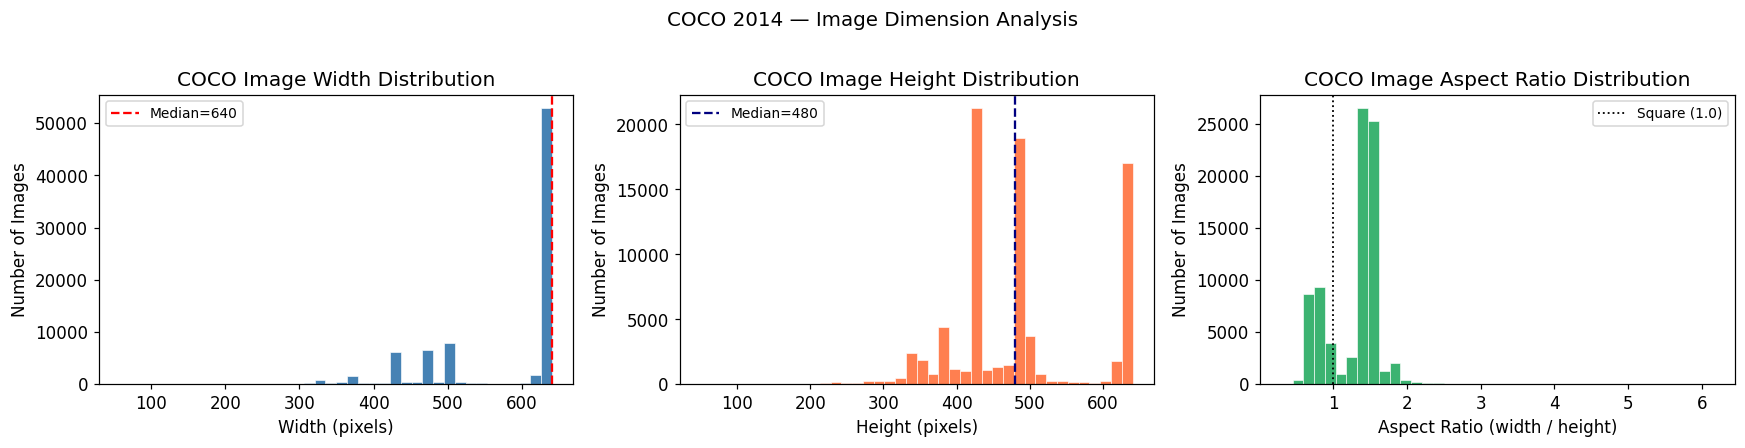

Saved -> d:\NLP-Research\module-2\outputs\eda\coco_image_dimensions.png


In [155]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Width
axes[0].hist(img_df['width'], bins=40, color='steelblue', edgecolor='white', lw=0.4)
axes[0].set_title('COCO Image Width Distribution')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Number of Images')
axes[0].axvline(img_df['width'].median(), color='red', ls='--', lw=1.5, label=f'Median={img_df["width"].median():.0f}')
axes[0].legend(fontsize=9)

# Height
axes[1].hist(img_df['height'], bins=40, color='coral', edgecolor='white', lw=0.4)
axes[1].set_title('COCO Image Height Distribution')
axes[1].set_xlabel('Height (pixels)')
axes[1].set_ylabel('Number of Images')
axes[1].axvline(img_df['height'].median(), color='navy', ls='--', lw=1.5, label=f'Median={img_df["height"].median():.0f}')
axes[1].legend(fontsize=9)

# Aspect ratio
axes[2].hist(img_df['aspect_ratio'], bins=40, color='mediumseagreen', edgecolor='white', lw=0.4)
axes[2].set_title('COCO Image Aspect Ratio Distribution')
axes[2].set_xlabel('Aspect Ratio (width / height)')
axes[2].set_ylabel('Number of Images')
axes[2].axvline(1.0, color='black', ls=':', lw=1.2, label='Square (1.0)')
axes[2].legend(fontsize=9)

plt.suptitle('COCO 2014 — Image Dimension Analysis', fontsize=13, y=1.01)
plt.tight_layout()
out = EDA_DIR / 'coco_image_dimensions.png'
plt.savefig(out, dpi=110, bbox_inches='tight')
plt.show()
print(f'Saved -> {out}')


### 2B — Annotation-Level Analysis

**What:** How many annotations does each image have on average?

**Why:** Images with many annotations tend to be visually complex ('crowded scenes').
High variance here signals that the dataset is not uniformly complex — some images are trivial (1 object),
others are challenging (50+ objects). This affects difficulty estimation.


In [156]:
anns_per_img = coco_df.groupby('image_id')['ann_id'].count()

print('ANNOTATIONS PER IMAGE — COCO')
print('=' * 45)
print(f'  Total annotations  : {len(coco_df):,}')
print(f'  Unique images      : {anns_per_img.shape[0]:,}')
print(f'  Min per image      : {anns_per_img.min()}')
print(f'  Max per image      : {anns_per_img.max()}')
print(f'  Mean per image     : {anns_per_img.mean():.2f}')
print(f'  Median per image   : {anns_per_img.median():.1f}')
print(f'  Std dev            : {anns_per_img.std():.2f}')
print()
print('Distribution percentiles:')
for p in [10,25,50,75,90,95,99]:
    print(f'  p{p:<3}: {np.percentile(anns_per_img, p):.0f}')


ANNOTATIONS PER IMAGE — COCO
  Total annotations  : 604,906
  Unique images      : 82,081
  Min per image      : 1
  Max per image      : 93
  Mean per image     : 7.37
  Median per image   : 4.0
  Std dev            : 7.41

Distribution percentiles:
  p10 : 1
  p25 : 2
  p50 : 4
  p75 : 10
  p90 : 17
  p95 : 22
  p99 : 33


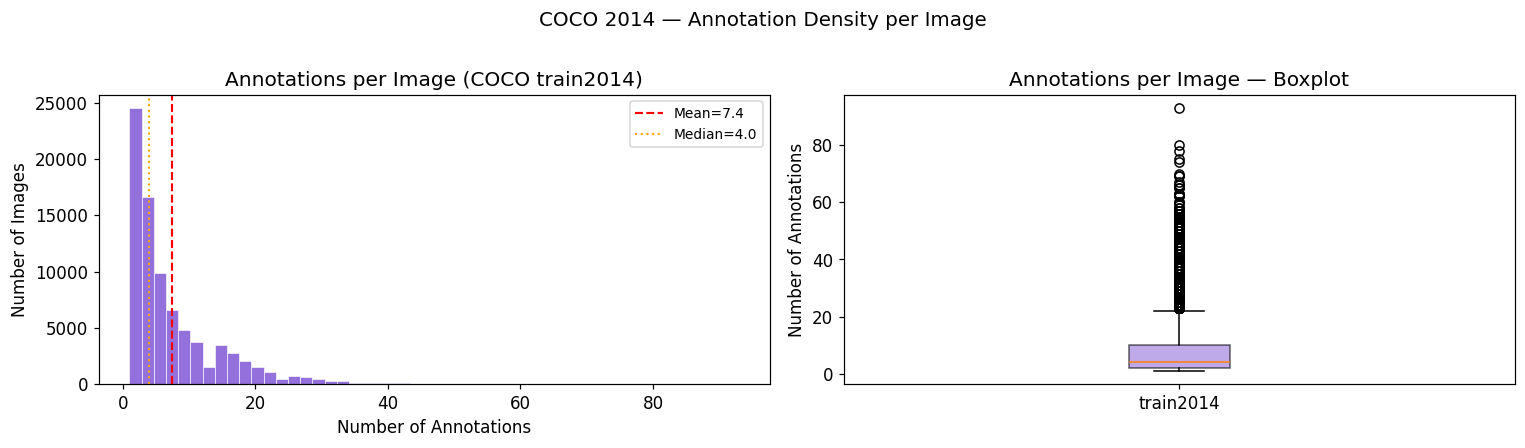

Saved -> d:\NLP-Research\module-2\outputs\eda\coco_annotations_per_image.png


In [157]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(anns_per_img, bins=50, color='mediumpurple', edgecolor='white', lw=0.4)
axes[0].set_title('Annotations per Image (COCO train2014)')
axes[0].set_xlabel('Number of Annotations')
axes[0].set_ylabel('Number of Images')
axes[0].axvline(anns_per_img.mean(),   color='red', ls='--', lw=1.4, label=f'Mean={anns_per_img.mean():.1f}')
axes[0].axvline(anns_per_img.median(), color='orange', ls=':', lw=1.4, label=f'Median={anns_per_img.median():.1f}')
axes[0].legend(fontsize=9)

# Box plot
axes[1].boxplot(anns_per_img, vert=True, patch_artist=True,
                boxprops=dict(facecolor='mediumpurple', alpha=0.6))
axes[1].set_title('Annotations per Image — Boxplot')
axes[1].set_ylabel('Number of Annotations')
axes[1].set_xticks([1]); axes[1].set_xticklabels(['train2014'])

plt.suptitle('COCO 2014 — Annotation Density per Image', fontsize=13, y=1.01)
plt.tight_layout()
out = EDA_DIR / 'coco_annotations_per_image.png'
plt.savefig(out, dpi=110, bbox_inches='tight')
plt.show()
print(f'Saved -> {out}')


### 2C — Category Analysis

**What:** Annotation frequency per COCO category.

**Why:** Category imbalance directly impacts model training — overrepresented classes dominate
gradient updates. Knowing the skew helps decide whether class-weighted loss or
oversampling/undersampling is needed.

**Imbalance metric:** Ratio of the most frequent category count to the least frequent.


In [158]:
cat_counts = coco_df['category_name'].value_counts()
n_cats = cat_counts.shape[0]

print(f'Total categories             : {n_cats}')
print(f'Most frequent category       : {cat_counts.index[0]}  ({cat_counts.iloc[0]:,} annotations)')
print(f'Least frequent category      : {cat_counts.index[-1]}  ({cat_counts.iloc[-1]:,} annotations)')
print(f'Imbalance ratio (max/min)    : {cat_counts.iloc[0]/cat_counts.iloc[-1]:.1f}x')
print()
print('Full category distribution:')
for cat, cnt in cat_counts.items():
    pct = cnt / len(coco_df) * 100
    print(f'  {cat:<25} {cnt:>8,}  ({pct:5.2f}%)')


Total categories             : 80
Most frequent category       : person  (185,315 annotations)
Least frequent category      : hair drier  (135 annotations)
Imbalance ratio (max/min)    : 1372.7x

Full category distribution:
  person                     185,315  (30.64%)
  car                         30,785  ( 5.09%)
  chair                       27,147  ( 4.49%)
  book                        17,315  ( 2.86%)
  bottle                      16,983  ( 2.81%)
  cup                         14,513  ( 2.40%)
  dining table                11,167  ( 1.85%)
  bowl                        10,064  ( 1.66%)
  traffic light                9,159  ( 1.51%)
  handbag                      8,778  ( 1.45%)
  umbrella                     7,865  ( 1.30%)
  boat                         7,590  ( 1.25%)
  bird                         7,290  ( 1.21%)
  truck                        7,050  ( 1.17%)
  banana                       6,912  ( 1.14%)
  bench                        6,751  ( 1.12%)
  sheep                 

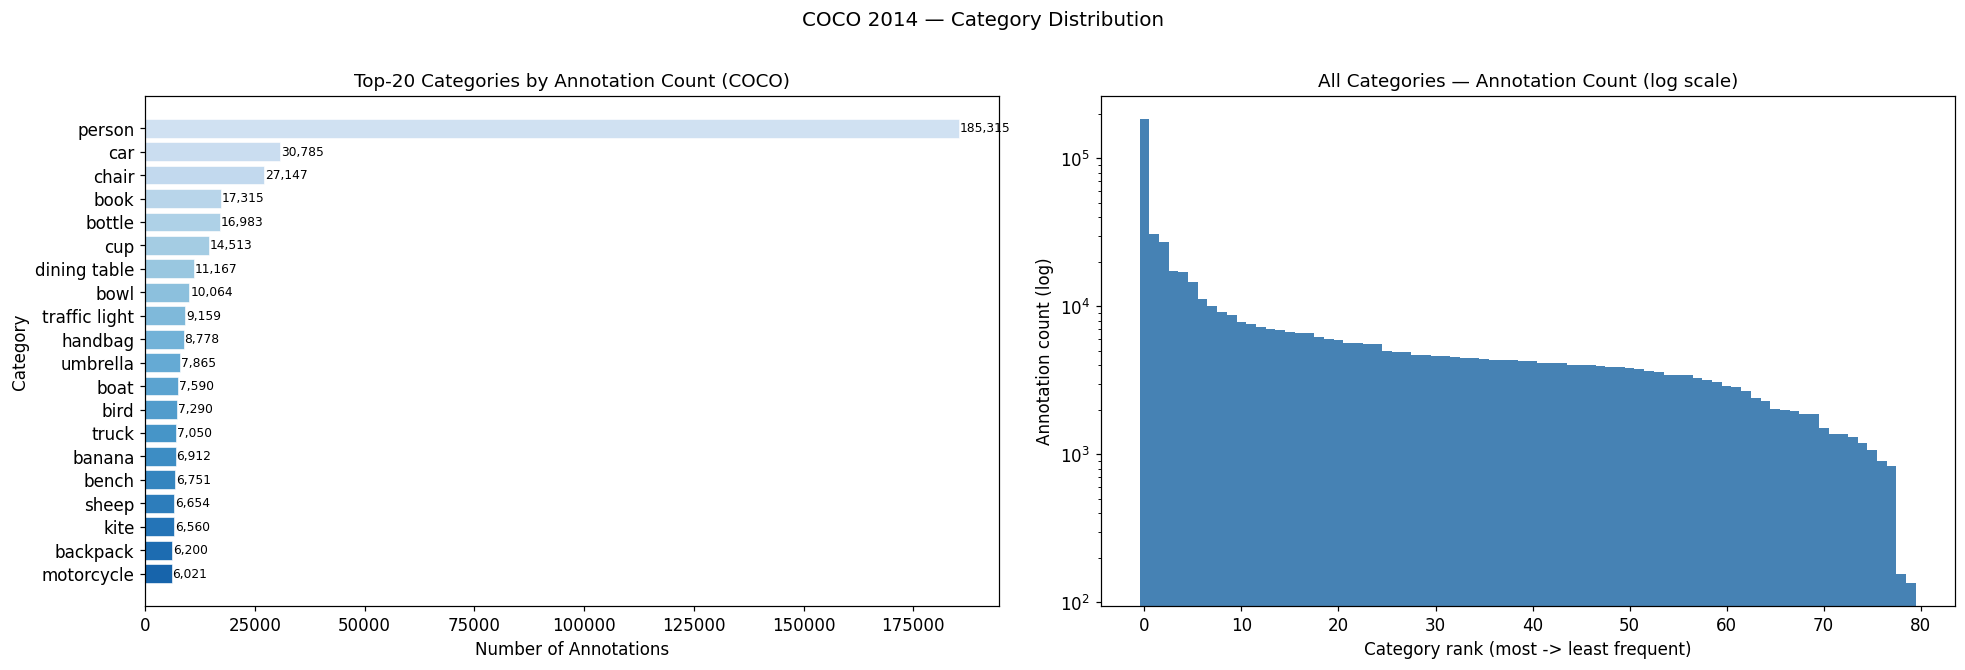

Saved -> d:\NLP-Research\module-2\outputs\eda\coco_category_distribution.png
Imbalance is SEVERE (ratio=1372.7x)


In [159]:
top20 = cat_counts.head(20)
bot10 = cat_counts.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top-20 bar
colors_t = plt.cm.Blues_r(np.linspace(0.2, 0.8, len(top20)))
bars = axes[0].barh(top20.index[::-1], top20.values[::-1],
                    color=colors_t, edgecolor='white', lw=0.4)
axes[0].set_title('Top-20 Categories by Annotation Count (COCO)', fontsize=12)
axes[0].set_xlabel('Number of Annotations')
axes[0].set_ylabel('Category')
for bar, v in zip(bars, top20.values[::-1]):
    axes[0].text(bar.get_width()+200, bar.get_y()+bar.get_height()/2,
                 f'{v:,}', va='center', fontsize=8)

# Log-scale all-category
axes[1].bar(range(n_cats), cat_counts.values, color='steelblue', edgecolor='none', width=1)
axes[1].set_yscale('log')
axes[1].set_title('All Categories — Annotation Count (log scale)', fontsize=12)
axes[1].set_xlabel('Category rank (most -> least frequent)')
axes[1].set_ylabel('Annotation count (log)')

plt.suptitle('COCO 2014 — Category Distribution', fontsize=13, y=1.01)
plt.tight_layout()
out = EDA_DIR / 'coco_category_distribution.png'
plt.savefig(out, dpi=110, bbox_inches='tight')
plt.show()
print(f'Saved -> {out}')
print(f'Imbalance is {"SEVERE" if cat_counts.iloc[0]/cat_counts.iloc[-1] > 10 else "MODERATE"} '
      f'(ratio={cat_counts.iloc[0]/cat_counts.iloc[-1]:.1f}x)')


### 2D — Bounding Box Analysis (COCO)

**What:** Distributions of bbox width, height, area, relative area (area / image area), and aspect ratio.

**Why:** The size distribution of ground-truth boxes reveals:
- Whether the dataset contains predominantly small objects (hard to detect) or large ones
- Whether certain categories dominate at a particular scale
- Anchor-box design requirements for detection/grounding models

**Relative area** = bbox_area / image_area — values near 0 are tiny objects; near 1 are objects filling the frame.


In [160]:
coco_df['bbox_area']     = coco_df['bbox_width'] * coco_df['bbox_height']
coco_df['image_area']    = coco_df['width'] * coco_df['height']
coco_df['bbox_rel_area'] = coco_df['bbox_area'] / coco_df['image_area']
coco_df['bbox_ar']       = coco_df['bbox_width'] / coco_df['bbox_height'].replace(0, np.nan)

print('BBOX STATISTICS — COCO')
print('=' * 55)
for col, label in [
    ('bbox_width',    'Width (px)'),
    ('bbox_height',   'Height (px)'),
    ('bbox_area',     'Area (px^2)'),
    ('bbox_rel_area', 'Relative area (0-1)'),
    ('bbox_ar',       'Aspect ratio (w/h)'),
]:
    s = coco_df[col].dropna()
    print(f'  {label:<25} min={s.min():.2f}  max={s.max():.2f}  '
          f'mean={s.mean():.2f}  median={s.median():.2f}')

# Flag tiny (<16x16 px) and huge (>90% rel area) boxes
tiny  = coco_df[(coco_df['bbox_width']<16) & (coco_df['bbox_height']<16)]
huge  = coco_df[coco_df['bbox_rel_area']>0.9]
print()
print(f'Tiny boxes  (<16x16 px)     : {len(tiny):,}  ({len(tiny)/len(coco_df)*100:.2f}%)')
print(f'Huge boxes  (>90% img area) : {len(huge):,}  ({len(huge)/len(coco_df)*100:.2f}%)')


BBOX STATISTICS — COCO
  Width (px)                min=0.57  max=640.00  mean=103.56  median=53.95
  Height (px)               min=0.34  max=640.00  mean=107.11  median=62.08
  Area (px^2)               min=1.21  max=409600.00  mean=21302.19  median=3282.43
  Relative area (0-1)       min=0.00  max=1.00  mean=0.08  median=0.01
  Aspect ratio (w/h)        min=0.04  max=143.77  mean=1.22  median=0.86

Tiny boxes  (<16x16 px)     : 44,614  (7.38%)
Huge boxes  (>90% img area) : 4,871  (0.81%)


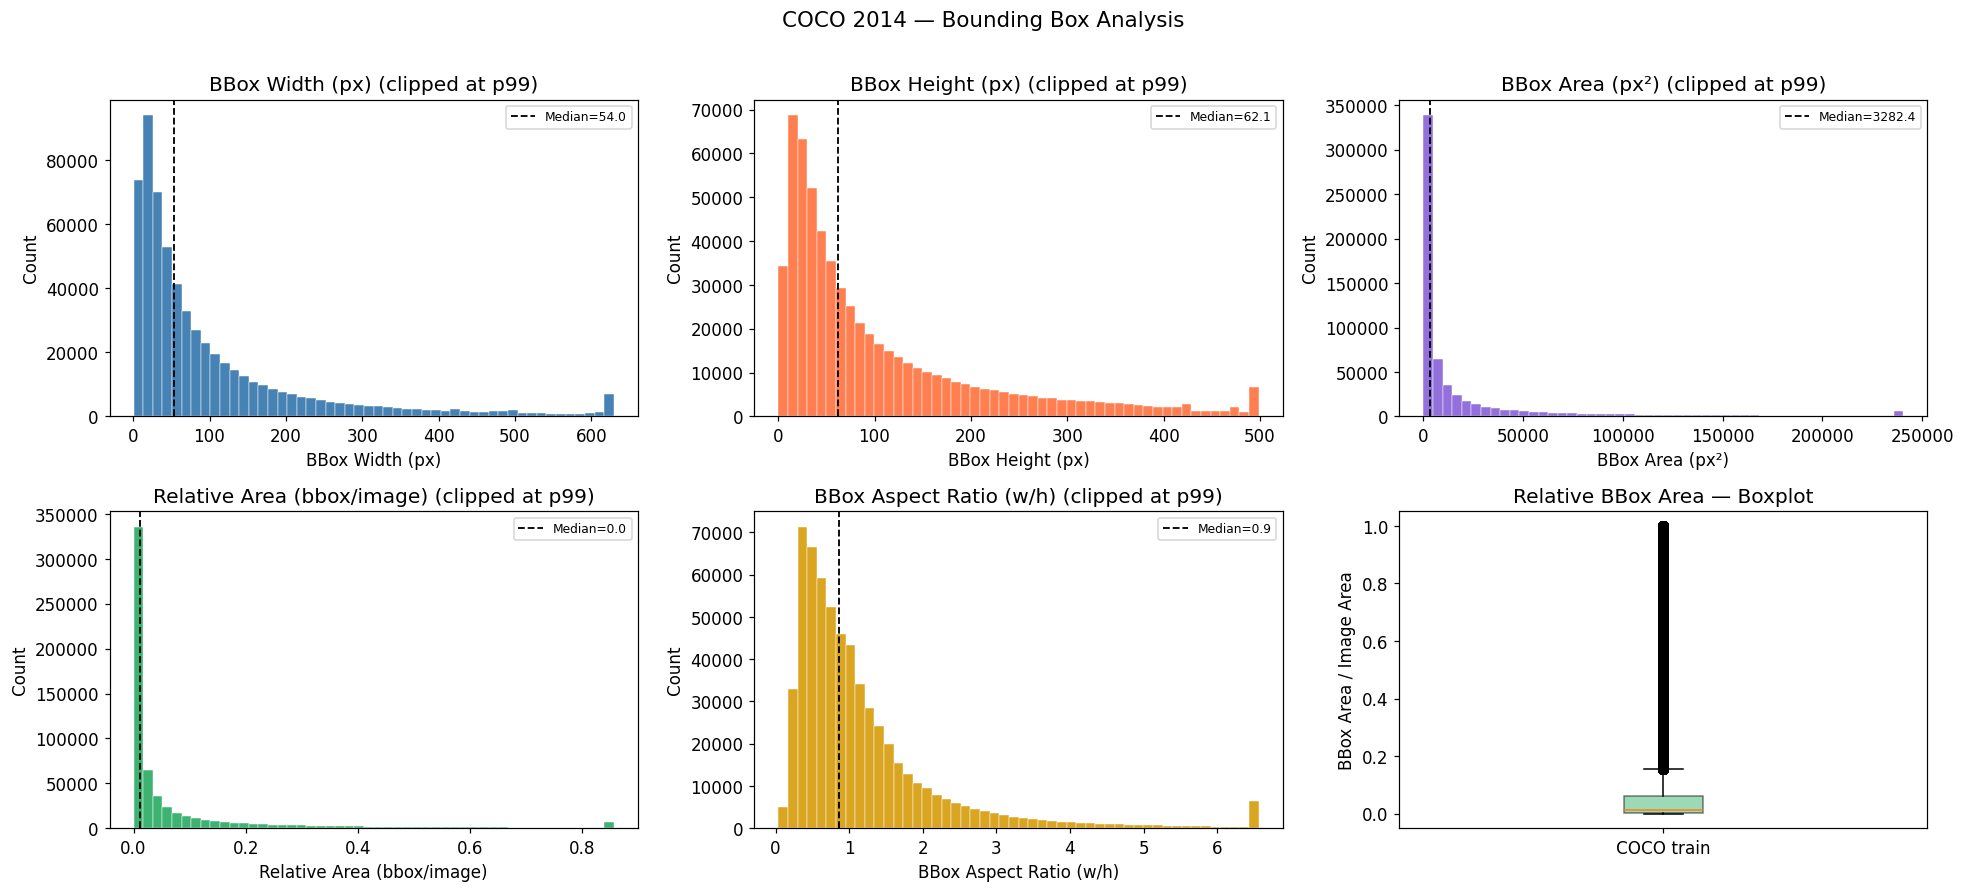

Saved -> d:\NLP-Research\module-2\outputs\eda\coco_bbox_analysis.png


In [161]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

specs = [
    ('bbox_width',    'BBox Width (px)',              'steelblue'),
    ('bbox_height',   'BBox Height (px)',             'coral'),
    ('bbox_area',     'BBox Area (px²)',              'mediumpurple'),
    ('bbox_rel_area', 'Relative Area (bbox/image)',   'mediumseagreen'),
    ('bbox_ar',       'BBox Aspect Ratio (w/h)',      'goldenrod'),
]

for ax, (col, xlabel, color) in zip(axes, specs):
    vals = coco_df[col].dropna()
    # clip to 99th percentile for readability
    p99  = np.percentile(vals, 99)
    ax.hist(vals.clip(upper=p99), bins=50, color=color, edgecolor='white', lw=0.3)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.set_title(f'{xlabel} (clipped at p99)')
    ax.axvline(vals.median(), color='black', ls='--', lw=1.2,
               label=f'Median={vals.median():.1f}')
    ax.legend(fontsize=8)

# Box plot of relative area in last panel
axes[5].boxplot(coco_df['bbox_rel_area'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='mediumseagreen', alpha=0.5))
axes[5].set_title('Relative BBox Area — Boxplot')
axes[5].set_ylabel('BBox Area / Image Area')
axes[5].set_xticks([1]); axes[5].set_xticklabels(['COCO train'])

plt.suptitle('COCO 2014 — Bounding Box Analysis', fontsize=14, y=1.01)
plt.tight_layout()
out = EDA_DIR / 'coco_bbox_analysis.png'
plt.savefig(out, dpi=110, bbox_inches='tight')
plt.show()
print(f'Saved -> {out}')


---
## Section 3 — RefCOCO EDA

**What:** Analyze the RefCOCO processed DataFrame across six dimensions:
basic statistics, split distribution, category distribution, expression length,
expression uniqueness, and target bounding boxes.

**Why:** RefCOCO is the core NLP component of this project. Understanding expression length,
vocabulary, and split balance directly informs model architecture and training decisions.

**Variable:** `refcoco_df` — one row per (expression, annotation) pair.


### 3A — Basic Statistics

**What:** Top-level counts for the RefCOCO processed dataset.

**Why:** Establishes baseline numbers that every subsequent analysis refers back to.


In [162]:
print('REFCOCO PROCESSED — BASIC STATISTICS')
print('=' * 55)
print(f'  Total rows (expressions)    : {len(refcoco_df):,}')
print(f'  Unique images               : {refcoco_df["image_id"].nunique():,}')
print(f'  Unique annotations (ann_id) : {refcoco_df["ann_id"].nunique():,}')
print(f'  Unique expressions          : {refcoco_df["referring_expression"].nunique():,}')
print(f'  Unique categories           : {refcoco_df["category_name"].nunique():,}')
print(f'  Sources                     : {sorted(refcoco_df["source"].unique())}')
print(f'  Splits                      : {sorted(refcoco_df["split"].unique())}')


REFCOCO PROCESSED — BASIC STATISTICS
  Total rows (expressions)    : 267,568
  Unique images               : 19,994
  Unique annotations (ann_id) : 50,000
  Unique expressions          : 76,672
  Unique categories           : 78
  Sources                     : ['google', 'unc']
  Splits                      : ['test', 'testA', 'testB', 'train', 'val']


### 3B — Split Distribution

**What:** Counts and percentages for each dataset split (train / val / testA / testB) broken down by source.

**Why:** An imbalanced split (e.g. testA >> testB) would affect evaluation reliability.
Knowing source (UNC vs Google) distribution also matters if we plan to use one source for training
and the other for evaluation.


In [163]:
coco_img_ids = set(coco_df['image_id'])
rc_img_ids   = set(refcoco_df['image_id'])
coco_ann_ids = set(coco_df['ann_id'])
rc_ann_ids   = set(refcoco_df['ann_id'])
coco_cats = set(coco_df['category_name'])
rc_cats   = set(refcoco_df['category_name'])

print('COCO <-> RefCOCO COVERAGE')
print('=' * 55)
print(f'  COCO total images             : {len(coco_img_ids):,}')
print(f'  RefCOCO unique images         : {len(rc_img_ids):,}')
print(f'  Image coverage                : {len(rc_img_ids)/len(coco_img_ids)*100:.2f}%')
print(f'  Images in RefCOCO NOT in COCO : {len(rc_img_ids - coco_img_ids):,}')
print()
print(f'  COCO total annotations        : {len(coco_ann_ids):,}')
print(f'  RefCOCO unique ann targets    : {len(rc_ann_ids):,}')
print(f'  Annotation coverage           : {len(rc_ann_ids)/len(coco_ann_ids)*100:.2f}%')
print()
print(f'  COCO categories               : {len(coco_cats)}')
print(f'  RefCOCO categories            : {len(rc_cats)}')
print(f'  Categories in COCO only       : {sorted(coco_cats - rc_cats)}')
print(f'  Categories in RefCOCO only    : {sorted(rc_cats - coco_cats)}')


COCO <-> RefCOCO COVERAGE
  COCO total images             : 82,081
  RefCOCO unique images         : 19,994
  Image coverage                : 24.36%
  Images in RefCOCO NOT in COCO : 0

  COCO total annotations        : 604,906
  RefCOCO unique ann targets    : 50,000
  Annotation coverage           : 8.27%

  COCO categories               : 80
  RefCOCO categories            : 78
  Categories in COCO only       : ['hair drier', 'toaster']
  Categories in RefCOCO only    : []


In [164]:
# ── Build split × source distribution table (needed by plot cells) ────────────
split_dist = (
    refcoco_df.groupby(['split', 'source'])
    .size()
    .unstack(fill_value=0)
)
split_dist['total']       = split_dist.sum(axis=1)
split_dist['pct_of_all']  = split_dist['total'] / split_dist['total'].sum() * 100

print('REFCOCO SPLIT × SOURCE DISTRIBUTION')
print(split_dist.to_string())


REFCOCO SPLIT × SOURCE DISTRIBUTION
source  google     unc   total  pct_of_all
split                                     
test     13368       0   13368      4.9961
testA        0    5349    5349      1.9991
testB        0    4794    4794      1.7917
train   107002  113373  220375     82.3622
val      13414   10268   23682      8.8508


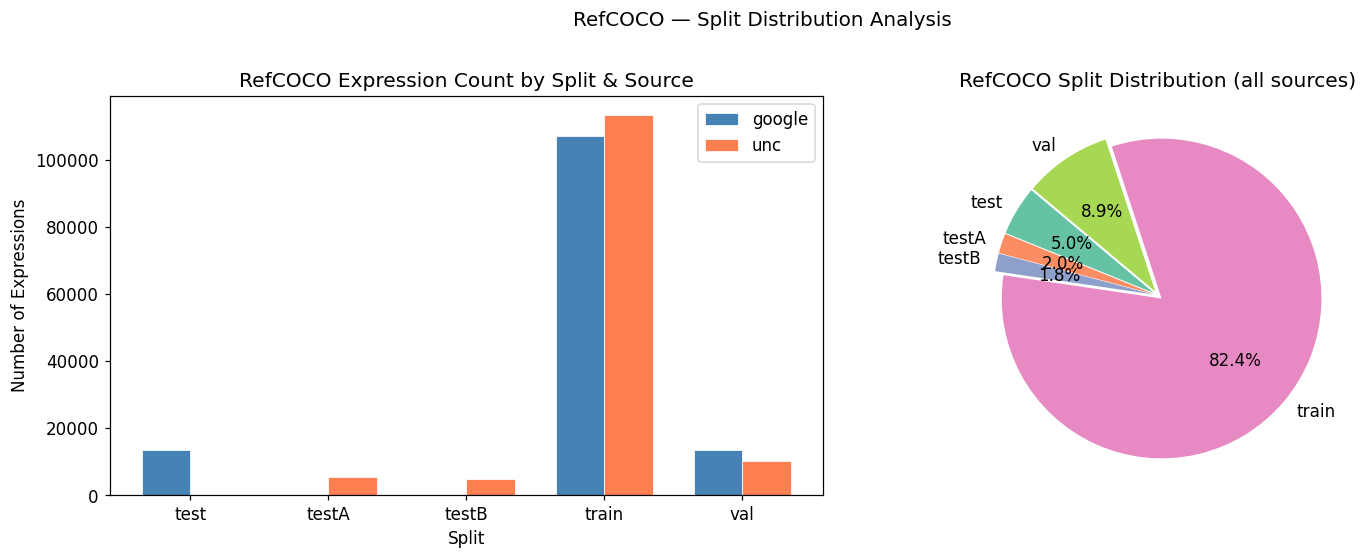

Saved -> d:\NLP-Research\module-2\outputs\eda\refcoco_split_distribution.png


In [165]:
splits  = split_dist.index.tolist()
sources = [c for c in split_dist.columns if c not in ('total','pct_of_all')]
x       = np.arange(len(splits))
width   = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grouped bar
colors_src = ['steelblue','coral','mediumseagreen']
for i, src in enumerate(sources):
    axes[0].bar(x + i*width, split_dist[src], width,
                label=src, color=colors_src[i % len(colors_src)],
                edgecolor='white', lw=0.5)
axes[0].set_xticks(x + width*(len(sources)-1)/2)
axes[0].set_xticklabels(splits)
axes[0].set_title('RefCOCO Expression Count by Split & Source')
axes[0].set_xlabel('Split')
axes[0].set_ylabel('Number of Expressions')
axes[0].legend()

# Total pie
totals  = split_dist['total']
explode = [0.03] * len(totals)
axes[1].pie(totals, labels=splits, autopct='%1.1f%%', explode=explode,
            colors=plt.cm.Set2.colors[:len(splits)], startangle=140)
axes[1].set_title('RefCOCO Split Distribution (all sources)')

plt.suptitle('RefCOCO — Split Distribution Analysis', fontsize=13, y=1.01)
plt.tight_layout()
out = EDA_DIR / 'refcoco_split_distribution.png'
plt.savefig(out, dpi=110, bbox_inches='tight')
plt.show()
print(f'Saved -> {out}')


### 3C — Category Distribution (RefCOCO)

**What:** How many referring expressions exist per object category?

**Why:** RefCOCO was originally built focusing on `person` and similar categories.
If the category distribution is highly concentrated, a model could cheat by
ignoring category information entirely. This also informs evaluation stratification.


In [166]:
rc_cat = refcoco_df['category_name'].value_counts()

print(f'Categories in RefCOCO : {len(rc_cat)}')
print()
print(f'{"Category":<25} {"Expressions":>12}  {"% of total":>10}')
print('-' * 52)
for cat, cnt in rc_cat.items():
    print(f'{cat:<25} {cnt:>12,}  {cnt/len(refcoco_df)*100:>9.2f}%')


Categories in RefCOCO : 78

Category                   Expressions  % of total
----------------------------------------------------
person                         134,252      50.17%
zebra                            5,482       2.05%
elephant                         5,480       2.05%
bowl                             5,434       2.03%
chair                            5,412       2.02%
giraffe                          5,306       1.98%
pizza                            4,460       1.67%
sandwich                         4,298       1.61%
donut                            4,136       1.55%
couch                            4,012       1.50%
cow                              3,960       1.48%
horse                            3,844       1.44%
motorcycle                       3,842       1.44%
sheep                            3,818       1.43%
teddy bear                       3,792       1.42%
car                              3,314       1.24%
suitcase                         3,198       1.20%
b

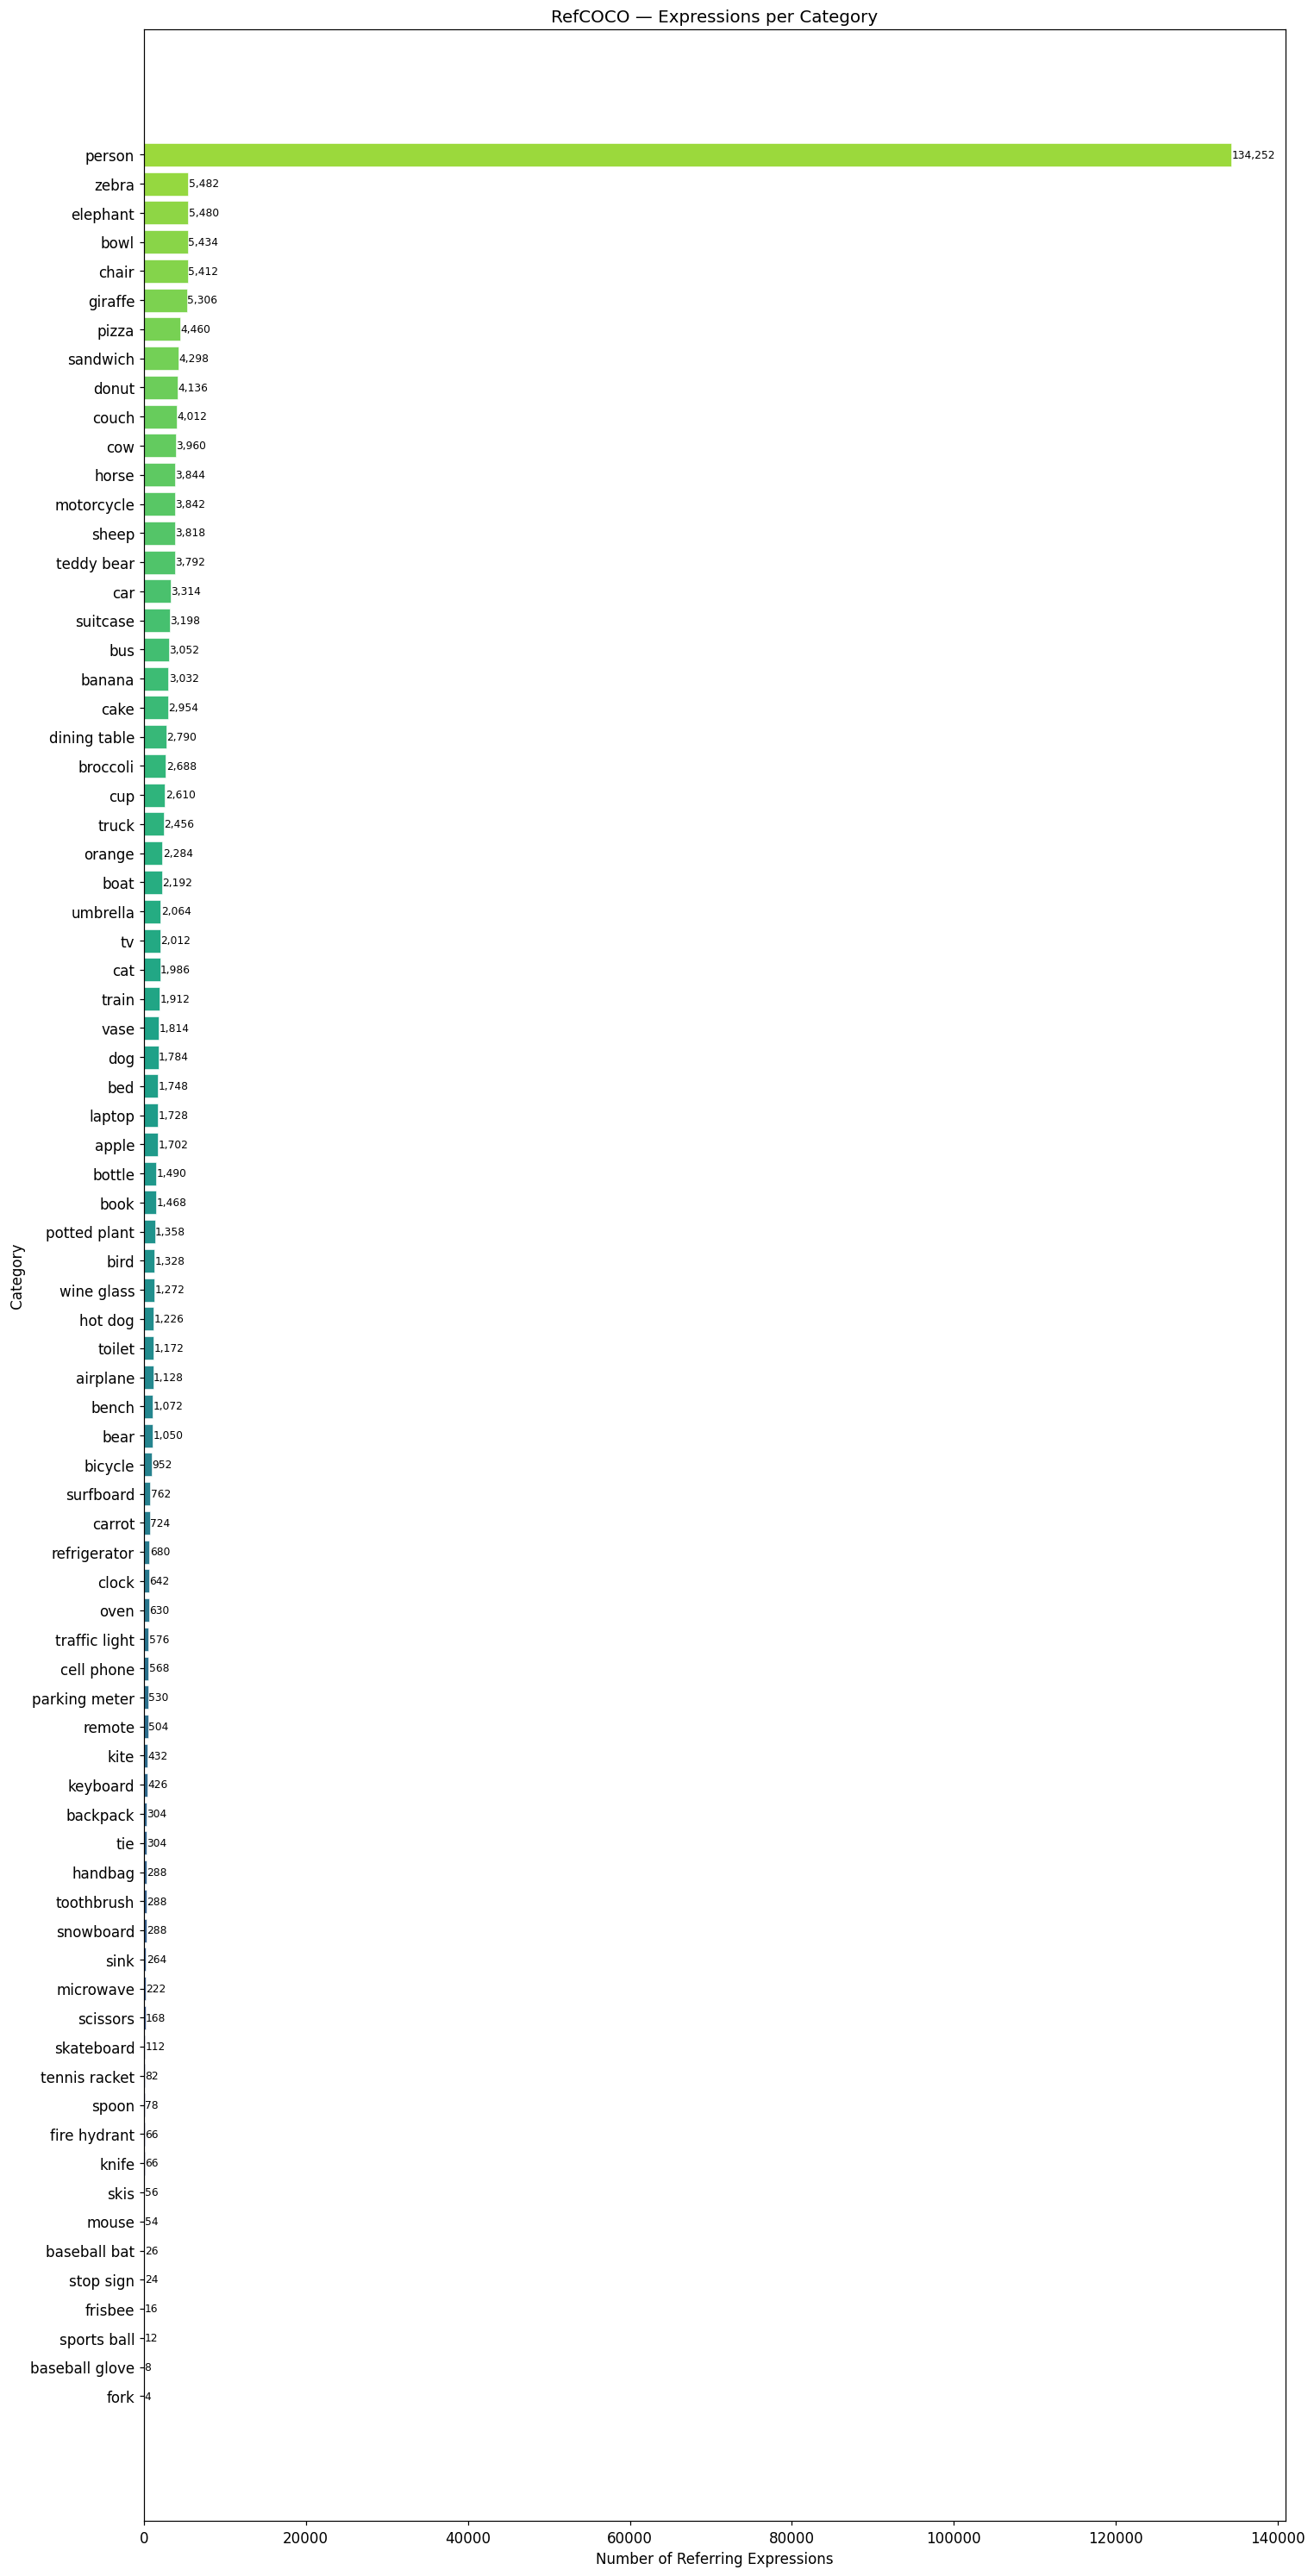

Saved -> d:\NLP-Research\module-2\outputs\eda\refcoco_category_distribution.png


In [167]:
fig, ax = plt.subplots(figsize=(14, max(5, len(rc_cat)*0.35)))
colors_c = plt.cm.viridis(np.linspace(0.15, 0.85, len(rc_cat)))
bars = ax.barh(rc_cat.index[::-1], rc_cat.values[::-1],
               color=colors_c, edgecolor='white', lw=0.4)
ax.set_title('RefCOCO — Expressions per Category', fontsize=13)
ax.set_xlabel('Number of Referring Expressions')
ax.set_ylabel('Category')
for bar, v in zip(bars, rc_cat.values[::-1]):
    ax.text(bar.get_width()+50, bar.get_y()+bar.get_height()/2,
            f'{v:,}', va='center', fontsize=8)
plt.tight_layout()
out = EDA_DIR / 'refcoco_category_distribution.png'
plt.savefig(out, dpi=110, bbox_inches='tight')
plt.show()
print(f'Saved -> {out}')


### 3D — Referring Expression Length Analysis

**What:** Distribution of expression length in both characters and words.

**Why:** Sequence length directly controls:
- Tokenizer padding/truncation settings
- Maximum sequence length hyperparameter for transformer models
- Memory requirements per training batch

**Variables:**
- `char_len` — number of characters in the expression
- `word_len` — number of whitespace-delimited tokens

**What we do NOT do:** modify expressions — this is read-only analysis.


In [168]:
refcoco_df['char_len'] = refcoco_df['referring_expression'].str.len()
refcoco_df['word_len'] = refcoco_df['referring_expression'].str.split().str.len()

print('REFERRING EXPRESSION LENGTH — STATISTICS')
print('=' * 55)
for col, label in [('char_len','Character length'),('word_len','Word count')]:
    s = refcoco_df[col].dropna()
    print(f'  {label}')
    print(f'    Min    : {s.min():.0f}')
    print(f'    Max    : {s.max():.0f}')
    print(f'    Mean   : {s.mean():.2f}')
    print(f'    Median : {s.median():.1f}')
    print(f'    Std    : {s.std():.2f}')
    for p in [25,50,75,90,95,99]:
        print(f'    p{p:<3}  : {np.percentile(s,p):.0f}')
    print()


REFERRING EXPRESSION LENGTH — STATISTICS
  Character length
    Min    : 1
    Max    : 190
    Mean   : 18.23
    Median : 16.0
    Std    : 10.58
    p25   : 11
    p50   : 16
    p75   : 23
    p90   : 32
    p95   : 39
    p99   : 53

  Word count
    Min    : 1
    Max    : 39
    Mean   : 3.60
    Median : 3.0
    Std    : 2.08
    p25   : 2
    p50   : 3
    p75   : 4
    p90   : 6
    p95   : 8
    p99   : 11



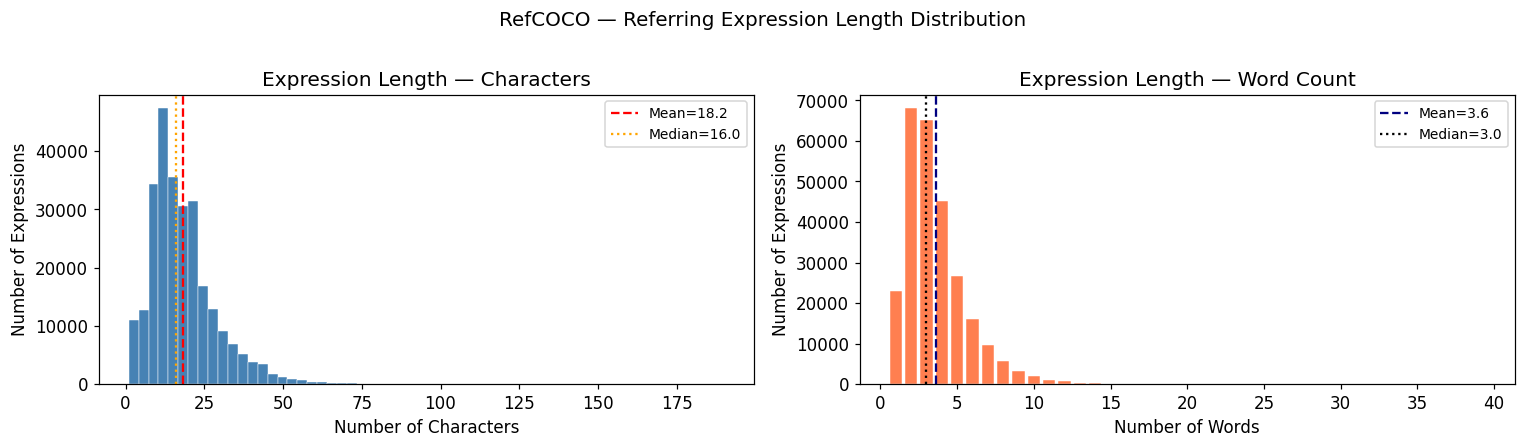

Saved -> d:\NLP-Research\module-2\outputs\eda\refcoco_expression_length.png


In [169]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Character length
axes[0].hist(refcoco_df['char_len'], bins=60, color='steelblue', edgecolor='white', lw=0.3)
axes[0].set_title('Expression Length — Characters')
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Number of Expressions')
axes[0].axvline(refcoco_df['char_len'].mean(),   color='red',    ls='--', lw=1.5, label=f'Mean={refcoco_df["char_len"].mean():.1f}')
axes[0].axvline(refcoco_df['char_len'].median(), color='orange', ls=':',  lw=1.5, label=f'Median={refcoco_df["char_len"].median():.1f}')
axes[0].legend(fontsize=9)

# Word count
wc_counts = refcoco_df['word_len'].value_counts().sort_index()
axes[1].bar(wc_counts.index, wc_counts.values, color='coral', edgecolor='white', lw=0.3, width=0.8)
axes[1].set_title('Expression Length — Word Count')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Number of Expressions')
axes[1].axvline(refcoco_df['word_len'].mean(),   color='navy',  ls='--', lw=1.5, label=f'Mean={refcoco_df["word_len"].mean():.1f}')
axes[1].axvline(refcoco_df['word_len'].median(), color='black', ls=':',  lw=1.5, label=f'Median={refcoco_df["word_len"].median():.1f}')
axes[1].legend(fontsize=9)

plt.suptitle('RefCOCO — Referring Expression Length Distribution', fontsize=13, y=1.01)
plt.tight_layout()
out = EDA_DIR / 'refcoco_expression_length.png'
plt.savefig(out, dpi=110, bbox_inches='tight')
plt.show()
print(f'Saved -> {out}')


In [170]:
# Shortest and longest expressions
print('SHORTEST EXPRESSIONS (by word count):')
shortest = refcoco_df.nsmallest(10, 'word_len')[['referring_expression','word_len','category_name','split']]
print(shortest.to_string(index=False))
print()
print('LONGEST EXPRESSIONS (by word count):')
longest = refcoco_df.nlargest(10, 'word_len')[['referring_expression','word_len','category_name','split']]
print(longest.to_string(index=False))
print()
print('RANDOM SAMPLE — 10 expressions:')
sample = refcoco_df[['referring_expression','word_len','category_name','split','source']].sample(10, random_state=99)
print(sample.to_string(index=False))


SHORTEST EXPRESSIONS (by word count):
referring_expression  word_len category_name split
            standing         1        person train
               woman         1        person train
                 man         1        person train
              middle         1          vase train
                 boy         1        person train
                 hat         1        person train
               woman         1        person train
                taxi         1           car testB
             chicken         1      sandwich train
                fist         1        person train

LONGEST EXPRESSIONS (by word count):
                                                                                                                                                                          referring_expression  word_len category_name split
the person the right who is up higher than the others and is wearing something on herhis head not sure of the sex of this one could go either 

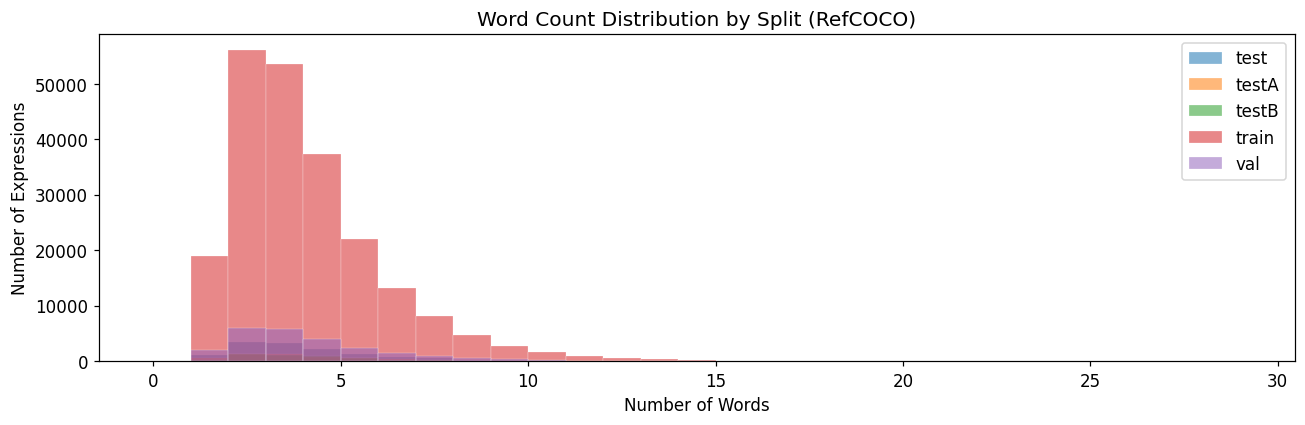

Saved -> d:\NLP-Research\module-2\outputs\eda\refcoco_wordcount_by_split.png


In [171]:
# Word-count distribution by split
fig, ax = plt.subplots(figsize=(12, 4))
for split in sorted(refcoco_df['split'].unique()):
    data = refcoco_df.loc[refcoco_df['split']==split, 'word_len']
    ax.hist(data, bins=range(0,30), alpha=0.55, label=split, edgecolor='white', lw=0.3)
ax.set_title('Word Count Distribution by Split (RefCOCO)')
ax.set_xlabel('Number of Words')
ax.set_ylabel('Number of Expressions')
ax.legend()
plt.tight_layout()
out = EDA_DIR / 'refcoco_wordcount_by_split.png'
plt.savefig(out, dpi=110, bbox_inches='tight')
plt.show()
print(f'Saved -> {out}')


### 3E — Referring Expression Uniqueness

**What:** How many expressions appear more than once in the dataset?

**Why:** A high duplication rate could indicate memorisability — a language model might learn to
output common phrases without actually understanding the visual scene. High uniqueness is desirable.

**Note:** Duplication here means identical text strings, not semantically equivalent expressions.


In [172]:
expr_counts = refcoco_df['referring_expression'].value_counts()

n_total_exprs  = len(refcoco_df)
n_unique_exprs = expr_counts.shape[0]
n_appear_once  = (expr_counts == 1).sum()
n_appear_multi = (expr_counts > 1).sum()

print('EXPRESSION UNIQUENESS')
print('=' * 50)
print(f'  Total expression rows         : {n_total_exprs:,}')
print(f'  Unique expressions            : {n_unique_exprs:,}  ({n_unique_exprs/n_total_exprs*100:.2f}%)')
print(f'  Appear exactly once           : {n_appear_once:,}  ({n_appear_once/n_total_exprs*100:.2f}%)')
print(f'  Appear 2+ times               : {n_appear_multi:,}')
print()
print('Most frequent expressions (top 20):')
print(expr_counts.head(20).to_string())


EXPRESSION UNIQUENESS
  Total expression rows         : 267,568
  Unique expressions            : 76,672  (28.66%)
  Appear exactly once           : 0  (0.00%)
  Appear 2+ times               : 76,672

Most frequent expressions (top 20):
referring_expression
woman              1638
man                1570
girl               1216
left guy           1148
right guy          1106
batter             1024
man on right        970
man on left         882
guy                 816
left person         794
guy on right        782
catcher             772
left                704
white shirt         698
guy on left         676
right person        624
red shirt           622
baby                598
blue shirt          574
person on right     570


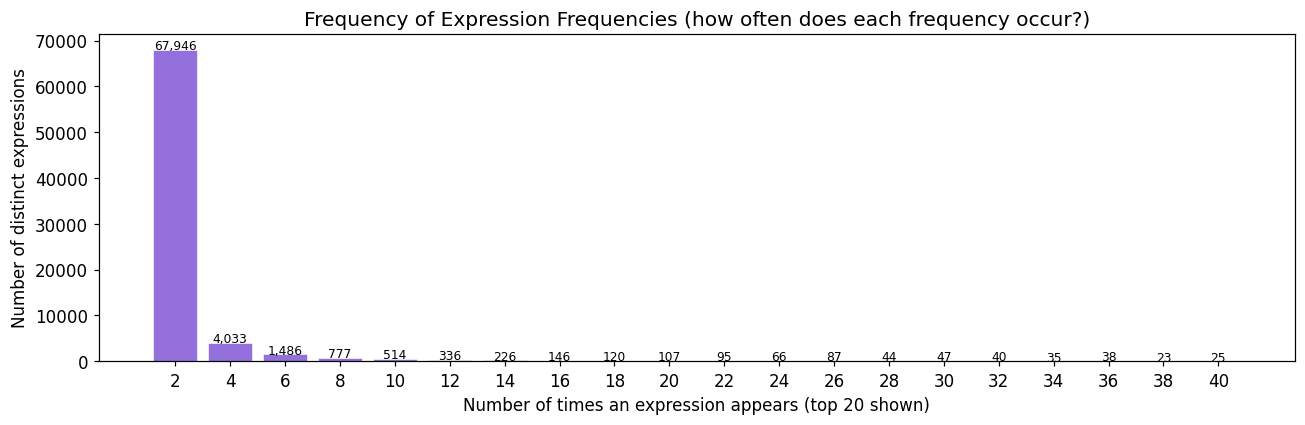

Saved -> d:\NLP-Research\module-2\outputs\eda\refcoco_expression_uniqueness.png


In [173]:
# Frequency-of-frequency histogram (how many expressions appear N times?)
freq_of_freq = expr_counts.value_counts().sort_index().head(20)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(freq_of_freq.index.astype(str), freq_of_freq.values,
       color='mediumpurple', edgecolor='white', lw=0.4)
ax.set_title('Frequency of Expression Frequencies (how often does each frequency occur?)')
ax.set_xlabel('Number of times an expression appears (top 20 shown)')
ax.set_ylabel('Number of distinct expressions')
for x_pos, v in zip(range(len(freq_of_freq)), freq_of_freq.values):
    ax.text(x_pos, v+50, f'{v:,}', ha='center', fontsize=8)
plt.tight_layout()
out = EDA_DIR / 'refcoco_expression_uniqueness.png'
plt.savefig(out, dpi=110, bbox_inches='tight')
plt.show()
print(f'Saved -> {out}')


### 3F — Target Bounding Box Analysis (RefCOCO)

**What:** Distributions of RefCOCO target bbox width, height, area, relative area, and aspect ratio.

**Why:** RefCOCO typically refers to a **single** salient object, so the bbox distribution here
may differ from COCO — expressions may preferentially target larger, more visible objects.
Comparing with COCO bbox distributions reveals selection bias in the annotation process.


In [174]:
# ── RefCOCO bounding box derived columns ─────────────────────────────────────
refcoco_df['bbox_area'] = refcoco_df['bbox_width'] * refcoco_df['bbox_height']

# width/height are NOT in refcoco_processed.csv — merge from coco_df
if 'width' not in refcoco_df.columns or refcoco_df['width'].isnull().all():
    img_dims   = coco_df[['image_id','width','height']].drop_duplicates('image_id')
    refcoco_df = refcoco_df.drop(columns=['image_area','width','height'], errors='ignore')
    refcoco_df = refcoco_df.merge(img_dims, on='image_id', how='left')

refcoco_df['image_area']    = refcoco_df['width'] * refcoco_df['height']
refcoco_df['bbox_rel_area'] = refcoco_df['bbox_area'] / refcoco_df['image_area']
refcoco_df['bbox_ar']       = refcoco_df['bbox_width'] / refcoco_df['bbox_height'].replace(0, np.nan)

print('REFCOCO TARGET BBOX STATISTICS')
print('=' * 55)
for col, label in [
    ('bbox_width',    'Width (px)'),
    ('bbox_height',   'Height (px)'),
    ('bbox_area',     'Area (px^2)'),
    ('bbox_rel_area', 'Relative area (0-1)'),
    ('bbox_ar',       'Aspect ratio (w/h)'),
]:
    s = refcoco_df[col].dropna()
    print(f'  {label:<25} min={s.min():.2f}  max={s.max():.2f}  '
          f'mean={s.mean():.2f}  median={s.median():.2f}')


REFCOCO TARGET BBOX STATISTICS
  Width (px)                min=29.94  max=640.00  mean=210.58  median=184.80
  Height (px)               min=24.23  max=640.00  mean=267.41  median=255.03
  Area (px^2)               min=10820.44  max=382220.98  mean=58414.48  median=43156.79
  Relative area (0-1)       min=0.03  max=1.00  mean=0.21  median=0.16
  Aspect ratio (w/h)        min=0.07  max=26.41  mean=0.93  median=0.76


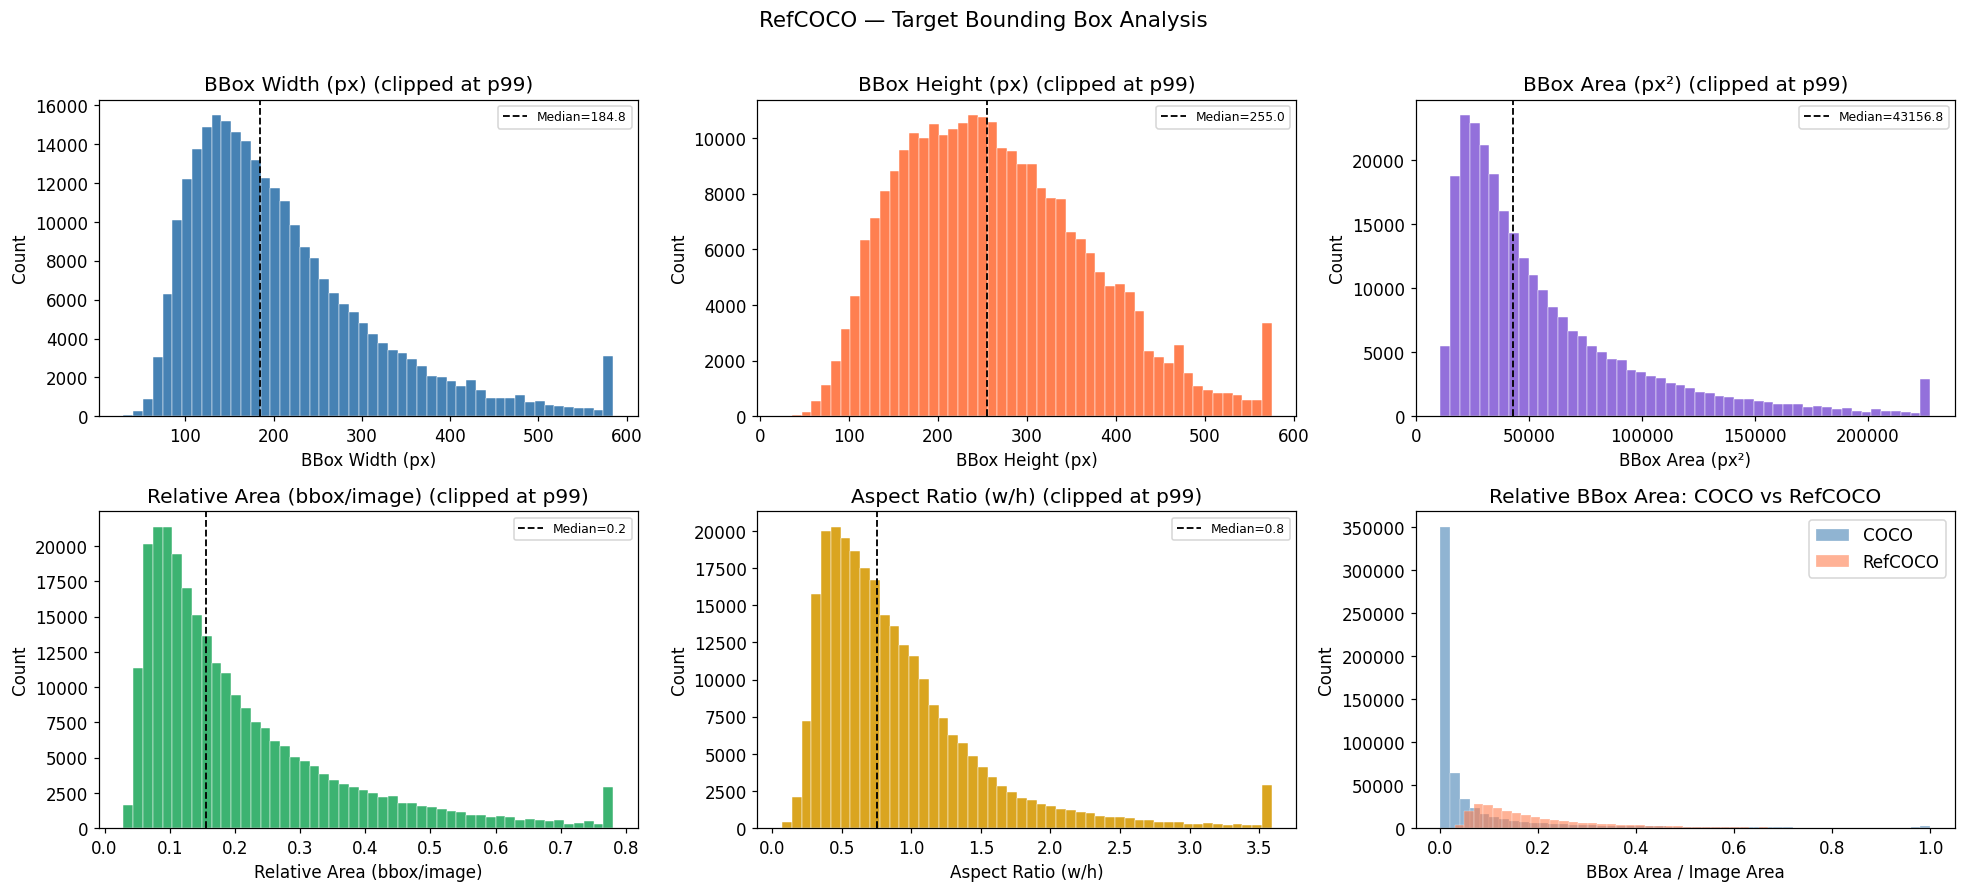

Saved -> d:\NLP-Research\module-2\outputs\eda\refcoco_bbox_analysis.png


In [175]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

specs_rc = [
    ('bbox_width',    'BBox Width (px)',            'steelblue'),
    ('bbox_height',   'BBox Height (px)',           'coral'),
    ('bbox_area',     'BBox Area (px²)',            'mediumpurple'),
    ('bbox_rel_area', 'Relative Area (bbox/image)', 'mediumseagreen'),
    ('bbox_ar',       'Aspect Ratio (w/h)',         'goldenrod'),
]

for ax, (col, xlabel, color) in zip(axes[:5], specs_rc):
    vals = refcoco_df[col].dropna()
    p99  = np.percentile(vals, 99)
    ax.hist(vals.clip(upper=p99), bins=50, color=color, edgecolor='white', lw=0.3)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.set_title(f'{xlabel} (clipped at p99)')
    ax.axvline(vals.median(), color='black', ls='--', lw=1.2,
               label=f'Median={vals.median():.1f}')
    ax.legend(fontsize=8)

# Compare COCO vs RefCOCO relative area in last panel
axes[5].hist(coco_df['bbox_rel_area'].dropna().clip(upper=1),    bins=50,
             color='steelblue', alpha=0.6, edgecolor='white', lw=0.3, label='COCO')
axes[5].hist(refcoco_df['bbox_rel_area'].dropna().clip(upper=1), bins=50,
             color='coral',     alpha=0.6, edgecolor='white', lw=0.3, label='RefCOCO')
axes[5].set_title('Relative BBox Area: COCO vs RefCOCO')
axes[5].set_xlabel('BBox Area / Image Area')
axes[5].set_ylabel('Count')
axes[5].legend()

plt.suptitle('RefCOCO — Target Bounding Box Analysis', fontsize=14, y=1.01)
plt.tight_layout()
out = EDA_DIR / 'refcoco_bbox_analysis.png'
plt.savefig(out, dpi=110, bbox_inches='tight')
plt.show()
print(f'Saved -> {out}')


---
## Section 4 — COCO ↔ RefCOCO Relationship EDA

**What:** Quantify how RefCOCO samples from the COCO image and annotation space.

**Why:** If RefCOCO only covers a small, biased fraction of COCO images, models trained on
RefCOCO may not generalise to the full COCO visual distribution. Understanding coverage
is essential before designing a training strategy.

**Key metrics:**
- Image coverage: what fraction of COCO train2014 images appear in RefCOCO?
- Annotation coverage: what fraction of COCO annotations are referred to?
- Category overlap: which COCO categories are represented in RefCOCO?


In [176]:
coco_img_ids    = set(coco_df['image_id'].unique())
rc_img_ids      = set(refcoco_df['image_id'].unique())
coco_ann_ids    = set(coco_df['ann_id'].unique())
rc_ann_ids      = set(refcoco_df['ann_id'].unique())
coco_cats       = set(coco_df['category_name'].unique())
rc_cats         = set(refcoco_df['category_name'].unique())

print('COCO <-> RefCOCO COVERAGE')
print('=' * 55)
print(f'  COCO total images             : {len(coco_img_ids):,}')
print(f'  RefCOCO unique images         : {len(rc_img_ids):,}')
print(f'  Image coverage                : {len(rc_img_ids)/len(coco_img_ids)*100:.2f}%')
print(f'  Images in RefCOCO NOT in COCO : {len(rc_img_ids - coco_img_ids):,}')
print()
print(f'  COCO total annotations        : {len(coco_ann_ids):,}')
print(f'  RefCOCO unique ann targets    : {len(rc_ann_ids):,}')
print(f'  Annotation coverage           : {len(rc_ann_ids)/len(coco_ann_ids)*100:.2f}%')
print()
print(f'  COCO categories               : {len(coco_cats)}')
print(f'  RefCOCO categories            : {len(rc_cats)}')
print(f'  Categories in COCO only       : {sorted(coco_cats - rc_cats)}')
print(f'  Categories in RefCOCO only    : {sorted(rc_cats - coco_cats)}')


COCO <-> RefCOCO COVERAGE
  COCO total images             : 82,081
  RefCOCO unique images         : 19,994
  Image coverage                : 24.36%
  Images in RefCOCO NOT in COCO : 0

  COCO total annotations        : 604,906
  RefCOCO unique ann targets    : 50,000
  Annotation coverage           : 8.27%

  COCO categories               : 80
  RefCOCO categories            : 78
  Categories in COCO only       : ['hair drier', 'toaster']
  Categories in RefCOCO only    : []


In [177]:
# Expressions per image distribution
exprs_per_img = refcoco_df.groupby('image_id').size()

print('REFCOCO EXPRESSIONS PER IMAGE')
print('=' * 45)
print(f'  Min    : {exprs_per_img.min()}')
print(f'  Max    : {exprs_per_img.max()}')
print(f'  Mean   : {exprs_per_img.mean():.2f}')
print(f'  Median : {exprs_per_img.median():.1f}')

# Top-10 most referenced images
top_imgs = exprs_per_img.nlargest(10)
print()
print('Top-10 most referenced images (by expression count):')
for img_id, cnt in top_imgs.items():
    img_path = coco_df.loc[coco_df['image_id']==img_id, 'image_path'].iloc[0] \
               if img_id in coco_df['image_id'].values else 'N/A'
    print(f'  image_id={img_id}  exprs={cnt}  file={img_path}')


REFCOCO EXPRESSIONS PER IMAGE
  Min    : 2
  Max    : 68
  Mean   : 13.38
  Median : 12.0

Top-10 most referenced images (by expression count):
  image_id=444598  exprs=68  file=COCO_train2014_000000444598.jpg
  image_id=184470  exprs=66  file=COCO_train2014_000000184470.jpg
  image_id=367538  exprs=60  file=COCO_train2014_000000367538.jpg
  image_id=513266  exprs=60  file=COCO_train2014_000000513266.jpg
  image_id=460986  exprs=58  file=COCO_train2014_000000460986.jpg
  image_id=15049  exprs=56  file=COCO_train2014_000000015049.jpg
  image_id=440160  exprs=56  file=COCO_train2014_000000440160.jpg
  image_id=394992  exprs=54  file=COCO_train2014_000000394992.jpg
  image_id=444799  exprs=54  file=COCO_train2014_000000444799.jpg
  image_id=46065  exprs=52  file=COCO_train2014_000000046065.jpg


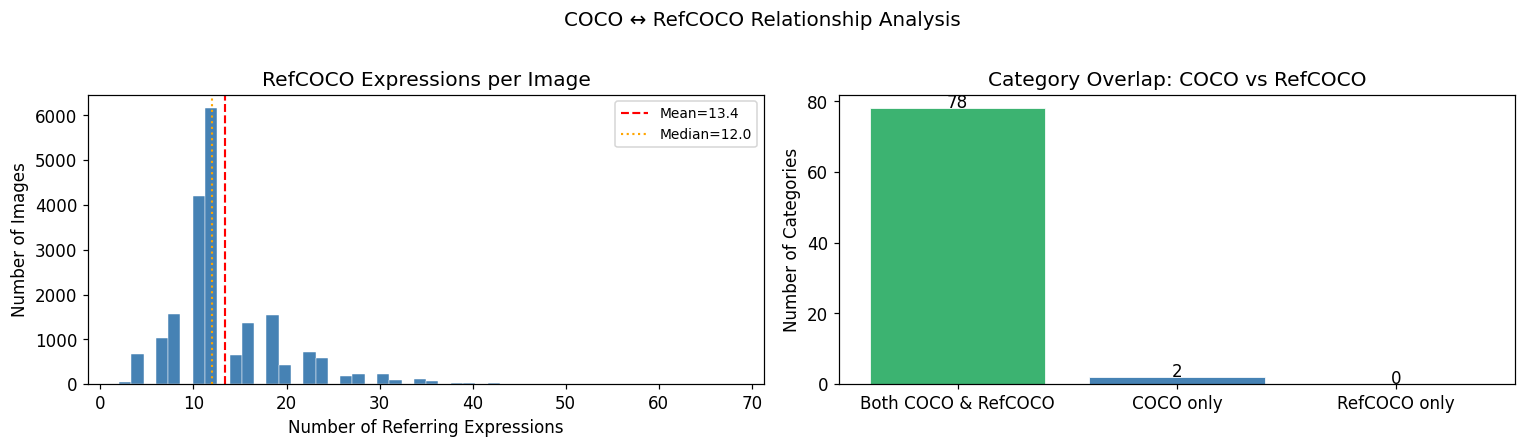

Saved -> d:\NLP-Research\module-2\outputs\eda\coco_refcoco_relationship.png


In [178]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram of expressions per image
axes[0].hist(exprs_per_img, bins=50, color='steelblue', edgecolor='white', lw=0.3)
axes[0].set_title('RefCOCO Expressions per Image')
axes[0].set_xlabel('Number of Referring Expressions')
axes[0].set_ylabel('Number of Images')
axes[0].axvline(exprs_per_img.mean(),   color='red',    ls='--', lw=1.4, label=f'Mean={exprs_per_img.mean():.1f}')
axes[0].axvline(exprs_per_img.median(), color='orange', ls=':',  lw=1.4, label=f'Median={exprs_per_img.median():.1f}')
axes[0].legend(fontsize=9)

# Venn-like bar — category overlap
cats_both  = coco_cats & rc_cats
cats_coco  = coco_cats - rc_cats
cats_rc    = rc_cats   - coco_cats
overlap_df = pd.DataFrame({
    'Group': ['Both COCO & RefCOCO', 'COCO only', 'RefCOCO only'],
    'Count': [len(cats_both), len(cats_coco), len(cats_rc)],
})
bars = axes[1].bar(overlap_df['Group'], overlap_df['Count'],
                   color=['mediumseagreen','steelblue','coral'],
                   edgecolor='white', lw=0.5)
axes[1].set_title('Category Overlap: COCO vs RefCOCO')
axes[1].set_ylabel('Number of Categories')
axes[1].set_xlabel('')
for bar, v in zip(bars, overlap_df['Count']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 str(v), ha='center', fontsize=11)

plt.suptitle('COCO ↔ RefCOCO Relationship Analysis', fontsize=13, y=1.01)
plt.tight_layout()
out = EDA_DIR / 'coco_refcoco_relationship.png'
plt.savefig(out, dpi=110, bbox_inches='tight')
plt.show()
print(f'Saved -> {out}')


---
## Section 5 — Text-Specific Linguistic Analysis

**What:** Analyze the vocabulary, word frequencies, and common linguistic patterns in RefCOCO expressions.

**Why:** This is an NLP project. Understanding what words annotators use reveals:
- Dominant vocabulary (informs tokeniser and embedding choices)
- Common positional terms (`left`, `right`, `top`, `bottom`)
- Common colour terms (`red`, `blue`, `white`, `black`)
- Common size terms (`large`, `small`, `big`, `little`)
- Whether expressions are mostly spatial, descriptive, or relational

**Method:** Simple whitespace tokenisation + lowercasing for frequency counting.
We do NOT remove stopwords here because in referring expressions, function words
(`the`, `on`, `left`) carry important spatial meaning.

**Variables:**
- `all_words` — flat list of all tokens across all expressions
- `word_freq` — Counter of token frequencies


In [179]:
# Tokenise all expressions
all_words = []
for expr in refcoco_df['referring_expression'].dropna():
    tokens = re.findall(r"[a-zA-Z']+", expr.lower())
    all_words.extend(tokens)

word_freq = Counter(all_words)
total_tokens = len(all_words)
vocab_size   = len(word_freq)

print('LEXICAL STATISTICS')
print('=' * 45)
print(f'  Total tokens (all expressions) : {total_tokens:,}')
print(f'  Vocabulary size (unique words) : {vocab_size:,}')
print(f'  Avg tokens per expression      : {total_tokens/len(refcoco_df):.2f}')
print()
print('Top 50 most frequent words:')
top50 = word_freq.most_common(50)
for i, (word, cnt) in enumerate(top50):
    pct = cnt/total_tokens*100
    print(f'  {i+1:>3}. {word:<15} {cnt:>8,}  ({pct:.3f}%)')


LEXICAL STATISTICS
  Total tokens (all expressions) : 961,454
  Vocabulary size (unique words) : 10,116
  Avg tokens per expression      : 3.59

Top 50 most frequent words:
    1. left              63,060  (6.559%)
    2. right             62,326  (6.482%)
    3. on                50,148  (5.216%)
    4. in                40,486  (4.211%)
    5. the               37,688  (3.920%)
    6. guy               22,116  (2.300%)
    7. man               21,078  (2.192%)
    8. shirt             16,974  (1.765%)
    9. of                15,908  (1.655%)
   10. front             15,814  (1.645%)
   11. person            14,608  (1.519%)
   12. white             14,510  (1.509%)
   13. with              14,364  (1.494%)
   14. bottom            13,704  (1.425%)
   15. middle            12,622  (1.313%)
   16. woman             12,460  (1.296%)
   17. top               12,260  (1.275%)
   18. girl              11,644  (1.211%)
   19. black             10,604  (1.103%)
   20. blue              10,5

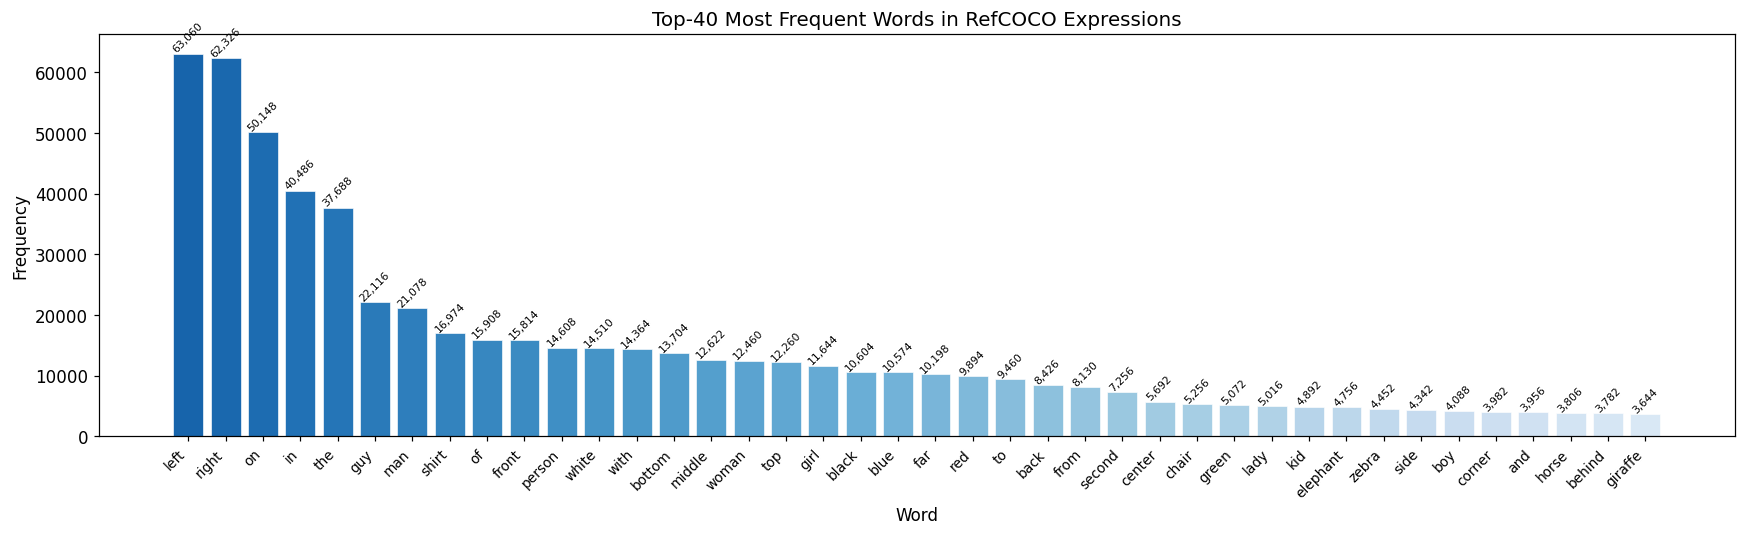

Saved -> d:\NLP-Research\module-2\outputs\eda\refcoco_word_frequency.png


In [180]:
# Top-40 word frequency bar chart
top40_words, top40_counts = zip(*word_freq.most_common(40))

fig, ax = plt.subplots(figsize=(16, 5))
colors_w = plt.cm.Blues_r(np.linspace(0.2, 0.85, len(top40_words)))
bars = ax.bar(range(len(top40_words)), top40_counts, color=colors_w,
              edgecolor='white', lw=0.4)
ax.set_xticks(range(len(top40_words)))
ax.set_xticklabels(top40_words, rotation=45, ha='right', fontsize=9)
ax.set_title('Top-40 Most Frequent Words in RefCOCO Expressions', fontsize=13)
ax.set_xlabel('Word')
ax.set_ylabel('Frequency')
for bar, v in zip(bars, top40_counts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
            f'{v:,}', ha='center', fontsize=7, rotation=45)
plt.tight_layout()
out = EDA_DIR / 'refcoco_word_frequency.png'
plt.savefig(out, dpi=110, bbox_inches='tight')
plt.show()
print(f'Saved -> {out}')


In [181]:
# Domain-specific term groups
SPATIAL_TERMS = ['left','right','top','bottom','middle','center','front','back',
                 'above','below','next','near','far','corner','side','behind',
                 'between','beside','under','over','above','upper','lower']

COLOR_TERMS   = ['red','blue','green','yellow','white','black','brown','orange',
                 'pink','purple','gray','grey','dark','light','bright','blonde']

SIZE_TERMS    = ['large','small','big','little','tiny','huge','tall','short',
                 'wide','narrow','thick','thin','long','smaller','larger','bigger']

PERSON_TERMS  = ['man','woman','person','people','boy','girl','child','kid',
                 'baby','player','guy','lady','men','women','standing','sitting']

print('DOMAIN-SPECIFIC TERM ANALYSIS')
print('=' * 55)
for group_name, terms in [
    ('Spatial / positional', SPATIAL_TERMS),
    ('Colour descriptors',   COLOR_TERMS),
    ('Size descriptors',     SIZE_TERMS),
    ('Person references',    PERSON_TERMS),
]:
    group_counts = {t: word_freq.get(t, 0) for t in terms}
    total_group  = sum(group_counts.values())
    top_in_group = sorted(group_counts.items(), key=lambda x: -x[1])[:8]
    print(f'  [{group_name}]  total occurrences={total_group:,}')
    for w, c in top_in_group:
        if c > 0:
            print(f'    {w:<12} : {c:,}')
    print()


DOMAIN-SPECIFIC TERM ANALYSIS
  [Spatial / positional]  total occurrences=226,670
    left         : 63,060
    right        : 62,326
    front        : 15,814
    bottom       : 13,704
    middle       : 12,622
    top          : 12,260
    far          : 10,198
    back         : 8,426

  [Colour descriptors]  total occurrences=70,190
    white        : 14,510
    black        : 10,604
    blue         : 10,574
    red          : 9,894
    green        : 5,072
    yellow       : 3,386
    orange       : 3,270
    brown        : 3,212

  [Size descriptors]  total occurrences=6,338
    big          : 1,980
    little       : 1,172
    small        : 910
    tall         : 524
    large        : 460
    long         : 426
    short        : 256
    smaller      : 226

  [Person references]  total occurrences=108,272
    guy          : 22,116
    man          : 21,078
    person       : 14,608
    woman        : 12,460
    girl         : 11,644
    lady         : 5,016
    kid          :

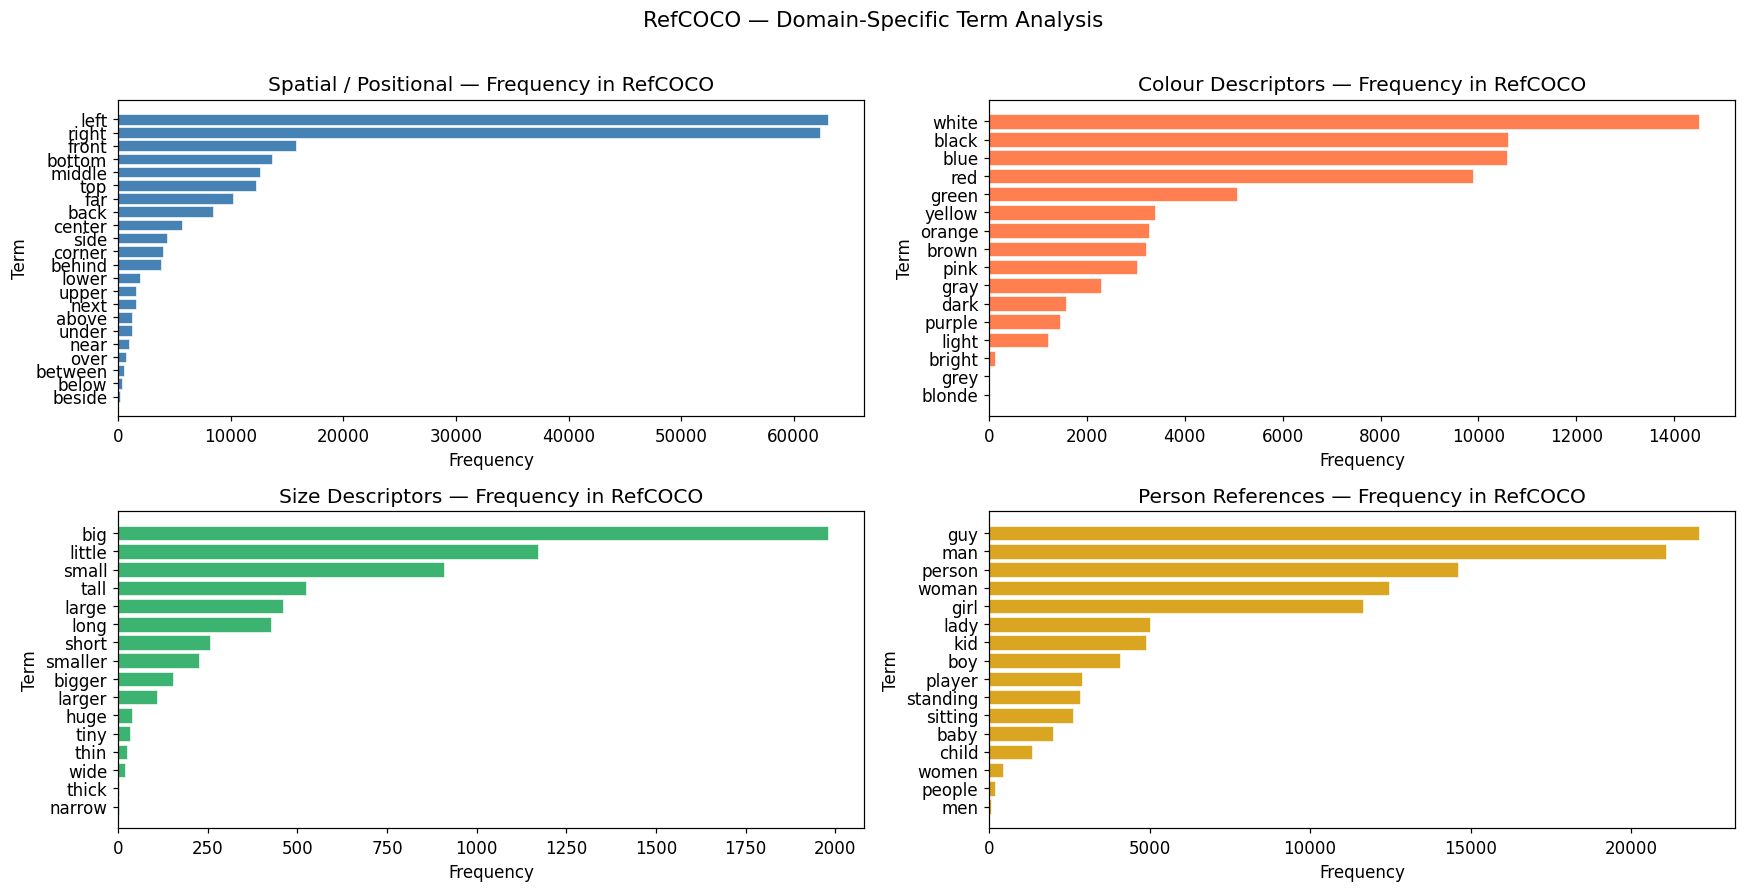

Saved -> d:\NLP-Research\module-2\outputs\eda\refcoco_domain_terms.png


In [182]:
# Visualise domain-term groups
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()

groups = [
    ('Spatial / Positional', SPATIAL_TERMS, 'steelblue'),
    ('Colour Descriptors',   COLOR_TERMS,   'coral'),
    ('Size Descriptors',     SIZE_TERMS,    'mediumseagreen'),
    ('Person References',    PERSON_TERMS,  'goldenrod'),
]

for ax, (title, terms, color) in zip(axes, groups):
    data = {t: word_freq.get(t, 0) for t in terms}
    data = dict(sorted(data.items(), key=lambda x: -x[1]))
    ax.barh(list(data.keys())[::-1], list(data.values())[::-1],
            color=color, edgecolor='white', lw=0.4)
    ax.set_title(f'{title} — Frequency in RefCOCO')
    ax.set_xlabel('Frequency')
    ax.set_ylabel('Term')

plt.suptitle('RefCOCO — Domain-Specific Term Analysis', fontsize=14, y=1.01)
plt.tight_layout()
out = EDA_DIR / 'refcoco_domain_terms.png'
plt.savefig(out, dpi=110, bbox_inches='tight')
plt.show()
print(f'Saved -> {out}')


---
## Section 6 — Data Quality Analysis

**What:** Systematic scan of both DataFrames for quality issues that might have survived preprocessing
or that are informative to report even if they are expected.

**Why:** Even after preprocessing, a quality audit confirms assumptions, documents known limitations,
and prevents silent errors from propagating into model training.

**Checks performed:**
1. Missing / null values
2. Invalid numerical values (negative, zero)
3. Zero or negative bbox dimensions
4. Duplicate rows
5. Inconsistent category IDs vs names
6. Invalid split labels
7. Expressions with zero words
8. RefCOCO images not in COCO

**Policy:** Report every issue; do not fix anything here.


In [183]:
issues = []  # accumulate (dataset, check, count, detail) tuples

def report(dataset, check, count, detail=''):
    status = 'ISSUE' if count > 0 else 'OK'
    print(f'  [{status}] {dataset:<12} | {check:<45} | n={count:,}  {detail}')
    issues.append({'dataset': dataset, 'check': check, 'count': count, 'detail': detail})

print('DATA QUALITY REPORT')
print('=' * 100)

# ── 1. Missing values ─────────────────────────────────────────────────────────
for df, name in [(coco_df, 'COCO'), (refcoco_df, 'RefCOCO')]:
    nulls = df.isnull().sum()
    for col, n in nulls.items():
        report(name, f'Null in {col}', n)

print()
# ── 2. Invalid numerical values (negative) ────────────────────────────────────
for df, name in [(coco_df, 'COCO'), (refcoco_df, 'RefCOCO')]:
    for col in ['bbox_x','bbox_y','bbox_width','bbox_height']:
        if col in df.columns:
            n = (df[col] < 0).sum()
            report(name, f'Negative {col}', n)

print()
# ── 3. Zero bbox dimensions ───────────────────────────────────────────────────
for df, name in [(coco_df, 'COCO'), (refcoco_df, 'RefCOCO')]:
    for col in ['bbox_width','bbox_height']:
        if col in df.columns:
            n = (df[col] == 0).sum()
            report(name, f'Zero {col}', n)

print()
# ── 4. Duplicate rows ─────────────────────────────────────────────────────────
report('COCO',    'Duplicate rows (all cols)',         coco_df.duplicated().sum())
report('COCO',    'Duplicate ann_ids',                 coco_df['ann_id'].duplicated().sum())
report('RefCOCO', 'Duplicate rows (all cols)',         refcoco_df.duplicated().sum())
report('RefCOCO', 'Duplicate (ann_id+expr+source)',
       refcoco_df.duplicated(subset=['ann_id','referring_expression','source']).sum())

print()
# ── 5. Category ID / name consistency ────────────────────────────────────────
for df, name in [(coco_df,'COCO'),(refcoco_df,'RefCOCO')]:
    if 'category_id' in df.columns and 'category_name' in df.columns:
        id_name_pairs = df.groupby('category_id')['category_name'].nunique()
        inconsistent  = (id_name_pairs > 1).sum()
        report(name, 'category_id maps to >1 name', inconsistent)

print()
# ── 6. Invalid split labels ───────────────────────────────────────────────────
valid_splits = {'train','val','testA','testB'}
if 'split' in refcoco_df.columns:
    bad_splits = (~refcoco_df['split'].isin(valid_splits)).sum()
    report('RefCOCO', 'Invalid split labels',
           bad_splits, f'valid={valid_splits}')

print()
# ── 7. Expressions with zero words ───────────────────────────────────────────
if 'word_len' in refcoco_df.columns:
    zero_word = (refcoco_df['word_len'] <= 0).sum()
    report('RefCOCO', 'Expressions with 0 words', zero_word)

print()
# ── 8. RefCOCO images not in COCO ─────────────────────────────────────────────
rc_not_in_coco = len(rc_img_ids - coco_img_ids)
report('RefCOCO', 'image_ids not found in COCO processed', rc_not_in_coco)

print()
print('=' * 100)
total_issues = sum(1 for r in issues if r['count'] > 0)
print(f'Total checks with issues : {total_issues} / {len(issues)}')


DATA QUALITY REPORT
  [OK] COCO         | Null in image_id                              | n=0  
  [OK] COCO         | Null in image_path                            | n=0  
  [OK] COCO         | Null in width                                 | n=0  
  [OK] COCO         | Null in height                                | n=0  
  [OK] COCO         | Null in ann_id                                | n=0  
  [OK] COCO         | Null in bbox_x                                | n=0  
  [OK] COCO         | Null in bbox_y                                | n=0  
  [OK] COCO         | Null in bbox_width                            | n=0  
  [OK] COCO         | Null in bbox_height                           | n=0  
  [OK] COCO         | Null in category_id                           | n=0  
  [OK] COCO         | Null in category_name                         | n=0  
  [OK] COCO         | Null in bbox_area                             | n=0  
  [OK] COCO         | Null in image_area                            

In [184]:
# Summary table
issues_df = pd.DataFrame(issues)
issues_df['status'] = issues_df['count'].apply(lambda x: 'ISSUE' if x > 0 else 'OK')
print('DATA QUALITY SUMMARY TABLE')
print(issues_df[['dataset','check','count','status']].to_string(index=False))


DATA QUALITY SUMMARY TABLE
dataset                                 check  count status
   COCO                      Null in image_id      0     OK
   COCO                    Null in image_path      0     OK
   COCO                         Null in width      0     OK
   COCO                        Null in height      0     OK
   COCO                        Null in ann_id      0     OK
   COCO                        Null in bbox_x      0     OK
   COCO                        Null in bbox_y      0     OK
   COCO                    Null in bbox_width      0     OK
   COCO                   Null in bbox_height      0     OK
   COCO                   Null in category_id      0     OK
   COCO                 Null in category_name      0     OK
   COCO                     Null in bbox_area      0     OK
   COCO                    Null in image_area      0     OK
   COCO                 Null in bbox_rel_area      0     OK
   COCO                       Null in bbox_ar      0     OK
RefCOCO      

---
## Section 7 — Save EDA Outputs

**What:** Persist machine-readable summaries as CSV files in `outputs/eda/`.

**Why:** CSV outputs allow downstream scripts and other team members to consume
EDA results programmatically without re-running the notebook.

**Files created:**
- `eda_summary.csv` — master summary of all key dataset statistics
- `category_distribution.csv` — per-category annotation and expression counts
- `expression_statistics.csv` — per-split expression length statistics

**Note:** Raw dataset files and preprocessed CSVs are NOT modified.


In [185]:
# ── eda_summary.csv ──────────────────────────────────────────────────────────
summary_rows = [
    # COCO
    ('COCO','unique_images',               coco_df['image_id'].nunique()),
    ('COCO','total_annotations',           len(coco_df)),
    ('COCO','unique_categories',           coco_df['category_name'].nunique()),
    ('COCO','img_width_mean',              img_df['width'].mean()),
    ('COCO','img_width_median',            img_df['width'].median()),
    ('COCO','img_height_mean',             img_df['height'].mean()),
    ('COCO','img_height_median',           img_df['height'].median()),
    ('COCO','anns_per_image_mean',         anns_per_img.mean()),
    ('COCO','anns_per_image_median',       anns_per_img.median()),
    ('COCO','anns_per_image_max',          anns_per_img.max()),
    ('COCO','bbox_width_mean',             coco_df['bbox_width'].mean()),
    ('COCO','bbox_height_mean',            coco_df['bbox_height'].mean()),
    ('COCO','bbox_rel_area_mean',          coco_df['bbox_rel_area'].mean()),
    ('COCO','bbox_rel_area_median',        coco_df['bbox_rel_area'].median()),
    ('COCO','tiny_boxes_lt16px',           int(len(tiny))),
    ('COCO','huge_boxes_gt90pct',          int(len(huge))),
    ('COCO','category_imbalance_ratio',    cat_counts.iloc[0]/cat_counts.iloc[-1]),
    # RefCOCO
    ('RefCOCO','total_rows',               len(refcoco_df)),
    ('RefCOCO','unique_images',            refcoco_df['image_id'].nunique()),
    ('RefCOCO','unique_ann_ids',           refcoco_df['ann_id'].nunique()),
    ('RefCOCO','unique_expressions',       refcoco_df['referring_expression'].nunique()),
    ('RefCOCO','unique_categories',        refcoco_df['category_name'].nunique()),
    ('RefCOCO','char_len_mean',            refcoco_df['char_len'].mean()),
    ('RefCOCO','char_len_median',          refcoco_df['char_len'].median()),
    ('RefCOCO','word_len_mean',            refcoco_df['word_len'].mean()),
    ('RefCOCO','word_len_median',          refcoco_df['word_len'].median()),
    ('RefCOCO','word_len_min',             refcoco_df['word_len'].min()),
    ('RefCOCO','word_len_max',             refcoco_df['word_len'].max()),
    ('RefCOCO','total_vocab_tokens',       total_tokens),
    ('RefCOCO','vocab_size',               vocab_size),
    ('RefCOCO','bbox_rel_area_mean',       refcoco_df['bbox_rel_area'].mean()),
    ('RefCOCO','bbox_rel_area_median',     refcoco_df['bbox_rel_area'].median()),
    ('RefCOCO','pct_unique_expressions',   refcoco_df['referring_expression'].nunique()/len(refcoco_df)*100),
    # Relationship
    ('Relationship','coco_images_in_refcoco',         len(rc_img_ids)),
    ('Relationship','coco_image_coverage_pct',         len(rc_img_ids)/len(coco_img_ids)*100),
    ('Relationship','annotation_coverage_pct',         len(rc_ann_ids)/len(coco_ann_ids)*100),
    ('Relationship','categories_shared',               len(cats_both)),
    ('Relationship','categories_coco_only',            len(cats_coco)),
    ('Relationship','categories_refcoco_only',         len(cats_rc)),
    ('Relationship','exprs_per_image_mean',            exprs_per_img.mean()),
    ('Relationship','exprs_per_image_max',             exprs_per_img.max()),
]

eda_summary_df = pd.DataFrame(summary_rows, columns=['dataset','metric','value'])
eda_summary_df['value'] = eda_summary_df['value'].apply(
    lambda x: round(x, 4) if isinstance(x, float) else x
)

out = EDA_DIR / 'eda_summary.csv'
eda_summary_df.to_csv(out, index=False)
print(f'Saved eda_summary.csv -> {out}  ({len(eda_summary_df)} rows)')


Saved eda_summary.csv -> d:\NLP-Research\module-2\outputs\eda\eda_summary.csv  (41 rows)


In [186]:
# ── category_distribution.csv ────────────────────────────────────────────────
coco_cat_df = coco_df['category_name'].value_counts().reset_index()
coco_cat_df.columns = ['category_name','coco_annotation_count']

rc_cat_df = refcoco_df['category_name'].value_counts().reset_index()
rc_cat_df.columns = ['category_name','refcoco_expression_count']

cat_dist_df = coco_cat_df.merge(rc_cat_df, on='category_name', how='outer').fillna(0)
cat_dist_df['refcoco_expression_count'] = cat_dist_df['refcoco_expression_count'].astype(int)
cat_dist_df = cat_dist_df.sort_values('coco_annotation_count', ascending=False)

out = EDA_DIR / 'category_distribution.csv'
cat_dist_df.to_csv(out, index=False)
print(f'Saved category_distribution.csv -> {out}  ({len(cat_dist_df)} rows)')
print()
print(cat_dist_df.to_string(index=False))


Saved category_distribution.csv -> d:\NLP-Research\module-2\outputs\eda\category_distribution.csv  (80 rows)

 category_name  coco_annotation_count  refcoco_expression_count
        person                 185315                    134252
           car                  30785                      3314
         chair                  27147                      5412
          book                  17315                      1468
        bottle                  16983                      1490
           cup                  14513                      2610
  dining table                  11167                      2790
          bowl                  10064                      5434
 traffic light                   9159                       576
       handbag                   8778                       288
      umbrella                   7865                      2064
          boat                   7590                      2192
          bird                   7290                     

In [187]:
# ── expression_statistics.csv ────────────────────────────────────────────────
expr_stats = (
    refcoco_df.groupby(['split','source'])['word_len']
    .agg(
        count='count',
        min_words='min',
        max_words='max',
        mean_words='mean',
        median_words='median',
        p25_words=lambda x: np.percentile(x, 25),
        p75_words=lambda x: np.percentile(x, 75),
        p95_words=lambda x: np.percentile(x, 95)
    )
    .reset_index()
)
expr_stats = expr_stats.round(3)

out = EDA_DIR / 'expression_statistics.csv'
expr_stats.to_csv(out, index=False)
print(f'Saved expression_statistics.csv -> {out}  ({len(expr_stats)} rows)')
print()
print(expr_stats.to_string(index=False))


Saved expression_statistics.csv -> d:\NLP-Research\module-2\outputs\eda\expression_statistics.csv  (7 rows)

split source  count  min_words  max_words  mean_words  median_words  p25_words  p75_words  p95_words
 test google  13368          1         35      3.6150        3.0000     2.0000     4.0000     8.0000
testA    unc   5349          1         23      3.5330        3.0000     2.0000     5.0000     7.0000
testB    unc   4794          1         27      3.7210        3.0000     2.0000     5.0000     8.0000
train google 107002          1         39      3.6000        3.0000     2.0000     4.0000     8.0000
train    unc 113373          1         39      3.5960        3.0000     2.0000     4.0000     8.0000
  val google  13414          1         27      3.6160        3.0000     2.0000     4.0000     8.0000
  val    unc  10268          1         21      3.6620        3.0000     2.0000     5.0000     8.0000


---
## Section 8 — Final EDA Summary

A consolidated narrative summary for researchers who want the key findings without reading every cell.


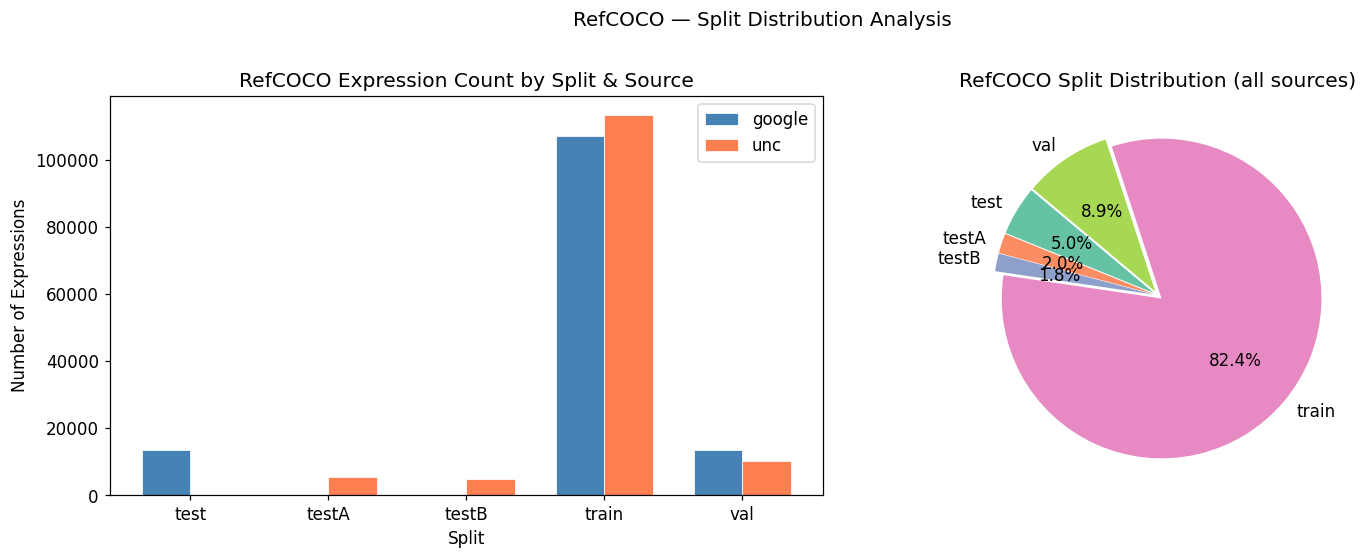

Saved -> d:\NLP-Research\module-2\outputs\eda\refcoco_split_distribution.png


In [188]:
splits_order = split_dist.index.tolist()
sources_cols  = [c for c in split_dist.columns if c not in ('total','pct_of_all')]
x       = np.arange(len(splits_order))
width   = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_src = ['steelblue','coral','mediumseagreen']
for i2, src2 in enumerate(sources_cols):
    axes[0].bar(x + i2*width, split_dist[src2], width,
                label=src2, color=colors_src[i2 % len(colors_src)],
                edgecolor='white', lw=0.5)
axes[0].set_xticks(x + width*(len(sources_cols)-1)/2)
axes[0].set_xticklabels(splits_order)
axes[0].set_title('RefCOCO Expression Count by Split & Source')
axes[0].set_xlabel('Split')
axes[0].set_ylabel('Number of Expressions')
axes[0].legend()

totals  = split_dist['total']
explode = [0.03] * len(totals)
axes[1].pie(totals, labels=splits_order, autopct='%1.1f%%', explode=explode,
            colors=plt.cm.Set2.colors[:len(splits_order)], startangle=140)
axes[1].set_title('RefCOCO Split Distribution (all sources)')

plt.suptitle('RefCOCO — Split Distribution Analysis', fontsize=13, y=1.01)
plt.tight_layout()
out = EDA_DIR / 'refcoco_split_distribution.png'
plt.savefig(out, dpi=110, bbox_inches='tight')
plt.show()
print(f'Saved -> {out}')


---
## Output File Verification

**What:** Confirm that every expected EDA output file was successfully created.

**Expected:** All files exist with non-zero size.


In [189]:
expected_outputs = [
    EDA_DIR / 'coco_image_dimensions.png',
    EDA_DIR / 'coco_annotations_per_image.png',
    EDA_DIR / 'coco_category_distribution.png',
    EDA_DIR / 'coco_bbox_analysis.png',
    EDA_DIR / 'refcoco_split_distribution.png',
    EDA_DIR / 'refcoco_category_distribution.png',
    EDA_DIR / 'refcoco_expression_length.png',
    EDA_DIR / 'refcoco_wordcount_by_split.png',
    EDA_DIR / 'refcoco_expression_uniqueness.png',
    EDA_DIR / 'refcoco_bbox_analysis.png',
    EDA_DIR / 'coco_refcoco_relationship.png',
    EDA_DIR / 'refcoco_word_frequency.png',
    EDA_DIR / 'refcoco_domain_terms.png',
    EDA_DIR / 'eda_summary.csv',
    EDA_DIR / 'category_distribution.csv',
    EDA_DIR / 'expression_statistics.csv',
]

print('EDA OUTPUT FILE VERIFICATION')
print('=' * 70)
all_ok = True
for path in expected_outputs:
    exists = path.exists()
    size   = path.stat().st_size if exists else 0
    ok     = exists and size > 0
    all_ok = all_ok and ok
    status = 'OK' if ok else 'MISSING/EMPTY'
    print(f'  [{status}] {path.name:<45} {size/1024:.1f} KB')

print()
print(f'All EDA outputs created successfully: {all_ok}')


EDA OUTPUT FILE VERIFICATION
  [OK] coco_image_dimensions.png                     57.9 KB
  [OK] coco_annotations_per_image.png                48.9 KB
  [OK] coco_category_distribution.png                79.5 KB
  [OK] coco_bbox_analysis.png                        122.8 KB
  [OK] refcoco_split_distribution.png                62.6 KB
  [OK] refcoco_category_distribution.png             180.6 KB
  [OK] refcoco_expression_length.png                 55.4 KB
  [OK] refcoco_wordcount_by_split.png                30.5 KB
  [OK] refcoco_expression_uniqueness.png             42.9 KB
  [OK] refcoco_bbox_analysis.png                     132.2 KB
  [OK] coco_refcoco_relationship.png                 53.3 KB
  [OK] refcoco_word_frequency.png                    78.0 KB
  [OK] refcoco_domain_terms.png                      110.3 KB
  [OK] eda_summary.csv                               1.4 KB
  [OK] category_distribution.csv                     1.5 KB
  [OK] expression_statistics.csv                     0

---
## Agent Task Summary

### Agent Task Summary

**Input files**
- `module-2/outputs/coco_processed.csv` — preprocessed COCO 2014 annotation table
- `module-2/outputs/refcoco_processed.csv` — preprocessed RefCOCO expression table

---

**Analyses performed**
- COCO image-level: width/height/aspect-ratio distributions
- COCO annotation density: annotations-per-image statistics and distribution
- COCO category frequency: full category count table + top-20 bar chart + log-scale all-category chart
- COCO bounding box: width, height, area, relative area, and aspect-ratio distributions; flagged tiny (<16 px) and huge (>90% rel area) boxes
- RefCOCO basic statistics: total rows, unique images/annotations/expressions/categories
- RefCOCO split × source distribution: counts and percentages for train/val/testA/testB × unc/google
- RefCOCO category frequency: per-category expression counts
- RefCOCO expression length: character and word-count distributions, shortest/longest examples, per-split breakdown
- RefCOCO expression uniqueness: frequency-of-frequency analysis
- RefCOCO target bbox: width/height/area/relative-area/aspect-ratio; visual comparison vs COCO
- COCO ↔ RefCOCO relationship: image/annotation coverage, category overlap, expressions-per-image distribution
- Linguistic analysis: total token count, vocabulary size, top-50 words, domain-specific term groups (spatial, colour, size, person)
- Data quality: 8-category systematic quality audit across both DataFrames

---

**Visualizations generated** (saved in `module-2/outputs/eda/`)
- `coco_image_dimensions.png` — width / height / aspect-ratio histograms
- `coco_annotations_per_image.png` — annotation density histogram + boxplot
- `coco_category_distribution.png` — top-20 bar chart + log-scale all-category chart
- `coco_bbox_analysis.png` — 5-panel bbox distribution grid + relative-area boxplot
- `refcoco_split_distribution.png` — grouped bar (split × source) + pie chart
- `refcoco_category_distribution.png` — horizontal bar chart of expressions per category
- `refcoco_expression_length.png` — character-length histogram + word-count bar chart
- `refcoco_wordcount_by_split.png` — overlaid word-count histograms per split
- `refcoco_expression_uniqueness.png` — frequency-of-frequency bar chart
- `refcoco_bbox_analysis.png` — 5-panel bbox distribution grid + COCO vs RefCOCO comparison
- `coco_refcoco_relationship.png` — expressions-per-image histogram + category overlap bar
- `refcoco_word_frequency.png` — top-40 word frequency bar chart
- `refcoco_domain_terms.png` — 4-panel domain-term frequency grid (spatial, colour, size, person)

---

**Statistics generated**
- Image dimension statistics (mean, median, std, min, max) for COCO
- Annotations-per-image statistics including percentile table
- Category imbalance ratio (max/min annotation count)
- BBox statistics: width, height, area, relative area, aspect ratio — for both COCO and RefCOCO
- Count of tiny boxes (<16×16 px) and huge boxes (>90% image area)
- Expression length statistics: character and word count (mean, median, min, max, percentiles)
- Vocabulary size and total token count
- Expression uniqueness ratio
- Image and annotation coverage percentages
- Domain-specific term frequencies (spatial, colour, size, person)

---

**Data quality checks**
- Null/missing values in all columns — both DataFrames
- Negative bbox coordinates
- Zero bbox width or height
- Duplicate rows (all-column and key-based)
- Category ID → name consistency
- Invalid split labels
- Expressions with zero words
- RefCOCO image IDs not found in COCO processed data

---

**Output files created** (`module-2/outputs/eda/`)
- 13 PNG visualisation files (listed above)
- `eda_summary.csv` — master EDA statistics table (dataset / metric / value)
- `category_distribution.csv` — per-category COCO annotation and RefCOCO expression counts
- `expression_statistics.csv` — per-split × per-source expression length statistics

---

**Important findings**
*(To be filled in by the researcher after running the notebook — findings depend on actual data values)*
- Category distribution: degree of skew and dominant categories
- Typical expression length (median word count)
- Image coverage of COCO by RefCOCO
- Presence or absence of quality issues in processed data
- Most frequent spatial/colour/size terms found in expressions

---

**Data modified?**
- **Raw datasets** (`module-2/datasets/`): **NOT modified** — read-only throughout.
- **Preprocessed CSVs** (`module-2/outputs/coco_processed.csv`, `refcoco_processed.csv`): **NOT modified** — read-only throughout.
- **New files created**: 13 PNG plots + 3 CSV summaries written to `module-2/outputs/eda/` only.
- Two derived columns (`char_len`, `word_len`) were added to the **in-memory** `refcoco_df` DataFrame during analysis. These were not written back to the preprocessed CSV.
